# OWSM + sEEG (B2T'25) — v6: barrido de ablaciones

> **v6 (revision completa del codigo).** Ocho correcciones y cuatro capacidades
> nuevas. Lo que hay que saber antes de tocar nada:
>
> **Errores corregidos**
> 1. `hacer_tag` no incluia `seed`, `unfreeze_*`, `init_encoder`, `norm`, `optim`,
>    `accum_grad` ni `holdout`, y de `objetivo_ctc` solo distinguia char. Tres
>    semillas del mismo modelo daban el mismo tag y `SKIP_IF_DONE` se saltaba dos
>    en silencio. Ahora el tag lleva una huella de la config completa.
> 2. `unfreeze_n_layers` descongelaba las **primeras** N capas del encoder, no las
>    ultimas. Nuevo parametro `unfreeze_ultimas`, que hace lo correcto.
> 3. `evaluar` (beam) medía sobre los N **primeros** trials y `evaluar_ctc_greedy`
>    sobre N repartidos: `cer_beam` y `cer_ctc_greedy` del CSV no eran comparables.
> 4. `stats_dir` solo distinguia `char` del resto: cualquier objetivo nuevo
>    reutilizaba los shape files del BPE, que tienen otras longitudes.
> 5. `patience_start_epoch` estaba fijo a 15 en el codigo e ignoraba el panel.
> 6. `copiar_sesion` daba por bueno cualquier fichero ya existente: una copia
>    truncada de Drive se quedaba truncada para siempre.
> 7. Las filas con error del CSV bloqueaban el reintento (`REPETIR_FALLIDOS`).
> 8. El reintento por OOM bajaba el batch sin subir `accum_grad`, cambiando el
>    batch efectivo sin avisar.
>
> **Capacidades nuevas**
> - `objetivo_ctc` ∈ {`char`, `fon`, `bpe256`, `word`, `bpe`} — los fonemas se leen
>   del propio HDF5, que los trae.
> - `init_encoder="random"` — el control cientifico.
> - `unfreeze_ultimas=N` — descongelacion parcial por arriba.
> - `holdout_sesiones=K` — dias enteros apartados del entrenamiento.
>
> **Discrepancia documentada, no corregida:** `aug_n_canales x aug_max_canales` es
> el numero EXACTO de electrodos anulados (40 en v3/v5), no un maximo sorteado. El
> codigo esta bien; lo que hay que corregir es como se describe en la memoria.

Adaptación del notebook local para Colab. Cambios principales respecto a la versión local:

## Novedades de esta versión (v5)

Tres cambios, cada uno respondiendo a algo que los resultados anteriores dejaron claro.

**1. Frontend `deep`.** El `linear` que se usó en casi todos los experimentos tenía 197 K parámetros y, peor, **descartaba 3 de cada 4 frames** por decimación (`x[:, ::4, :]`). El frontend original de OWSM tiene ~20 M. El nuevo `deep` es:

```
capa por sesión → Linear(512→d) + LayerNorm + GELU     ← mezcla espacial de electrodos
                → [Conv1d stride 2 → n bloques residuales] × 2   ← temporal, sin descartar frames
                → Linear(d→384) + codificación posicional
```

Con `deep_dim=512, deep_bloques=2` son **8,3 M** de parámetros (más 11,8 M de la capa por sesión con 45 sesiones). La mezcla de electrodos es todos-con-todos, no convolucional: el orden de los electrodos es arbitrario, así que convolucionar sobre ese eje (lo que hace `conv2d`, heredado de tratarlo como eje de frecuencias) no tiene sentido físico aquí.

**2. InterCTC.** Pérdidas CTC auxiliares en las capas 2 y 4 del encoder, compartiendo la misma cabeza. Es la receta estándar de ESPnet contra el subajuste en encoders profundos: da señal de gradiente directa a las capas de abajo en vez de que tenga que propagarse desde el final. Se activa con `interctc_weight=0.3`.

**3. Las 45 sesiones.** `SOLO_SESIONES_COMPLETAS` pasa a `False`. Antes se usaban 41 porque 4 sesiones no tienen `data_val.hdf5` y el filtro las descartaba enteras; ahora aportan datos de entrenamiento y simplemente no entran en validación. (De paso, el nombre de `stats_dir` ahora lleva el número real de sesiones, porque con el filtro activado o no `n_sessions=45` producía dos conjuntos de datos distintos con la misma carpeta de estadísticas.)

## Cómo usarlo

1. **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU L4**. Marca *High RAM* solo si vas a usar `n_sessions >= 30` con `PRELOAD_RAM = True`.
2. Comprueba que `DRIVE_DATA` (celda 1) apunta a tu carpeta `hdf5_data_final` en Drive.
3. Ejecuta las celdas 0 a 10 en orden. Reinicia el entorno cuando te lo pida la celda de instalación.
4. Edita la lista `BARRIDO` (celda 11) y lanza la celda 12.

Los resultados se van acumulando en `resultados.csv` en tu Drive: si Colab te desconecta, vuelves a lanzar y se salta los experimentos ya hechos.

## 0. Instalación

**Ejecuta esta celda, reinicia el entorno (`Entorno de ejecución → Reiniciar sesión`) y continúa desde la celda 1.**

Se instala **todo** aquí —ESPnet, kenlm y pyctcdecode— aunque el modelo de lenguaje no se use hasta la sección 13. No es por comodidad: instalar a mitad de sesión cambia numpy en disco bajo un kernel que ya lo tiene cargado, y a partir de ahí scipy falla con errores que no señalan la causa.

**El problema de fondo son las dependencias de numpy, y hay dos trampas distintas:**

1. **`pyctcdecode 0.5.0` declara `numpy<2.0.0`** mientras que `espnet 202511` declara `numpy>=2.0.0`. Incompatibles sobre el papel, así que pyctcdecode se instala con `--no-deps`. Su pin está obsoleto: funciona bien con numpy 2, solo usa operaciones básicas de array.

2. **`espnet → librosa → numba`, y numba pone tope superior a numpy.** `numba 0.61.0` exige `numpy<2.2`, así que pip degrada numpy a 2.1.3. Como Colab trae numpy 2.4+ y su scipy está compilado contra esa versión, el resultado es `ImportError: cannot import name '_slice' from 'numpy._core.umath'`. Un `pip install -U "numpy>=2"` **no** lo arregla, porque 2.1.3 ya cumple `>=2`.

La solución de (2) es un fichero de *constraints* que clava numpy en la versión que trae Colab durante toda la instalación. Así pip no puede moverlo: en vez de degradar numpy para contentar a numba, busca una numba compatible con el numpy que hay (`0.67`, que admite `numpy<2.6`). Si no encuentra solución, falla ruidosamente, que es mucho mejor que degradar numpy en silencio.

La celda termina verificando en un **proceso limpio** que numpy, scipy, torch, espnet, kenlm y pyctcdecode importan todos juntos. Si esa verificación pasa, el reinicio no te va a dar sorpresas.

In [1]:
!nvidia-smi

# ══════════════════════════════════════════════════════════════════════
# INSTALACION UNICA (v6.2). Al terminar: REINICIA EL ENTORNO.
# ══════════════════════════════════════════════════════════════════════
import importlib.util, subprocess, sys, os, textwrap

def sh(cmd, titulo=None, critico=True):
    """Ejecuta y solo escupe la salida si falla (los logs de apt son ruido)."""
    if titulo:
        print(f"  {titulo} ...", end=" ", flush=True)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    ok = r.returncode == 0
    if titulo:
        print("ok" if ok else "FALLO", flush=True)
    if not ok:
        print(textwrap.indent((r.stdout + r.stderr)[-3000:], "    "))
        if critico:
            raise RuntimeError(f"Fallo: {cmd}")
    return ok

def probar(codigo):
    """Importa en un proceso NUEVO. Es la unica prueba que vale: este kernel
    ya tiene modulos cargados en memoria y puede dar un falso positivo."""
    r = subprocess.run([sys.executable, "-c", codigo],
                       capture_output=True, text=True)
    lineas = r.stderr.strip().splitlines()
    return r.returncode == 0, r.stdout.strip(), (lineas[-1] if lineas else "")

# ── 0. Cual es el numpy bueno de esta VM ──────────────────────────────
# El scipy que trae Colab esta compilado contra SU numpy. Ese es el que hay
# que preservar. Si ya viene roto de un intento anterior, se restaura.
ok, ver_numpy, err = probar("import scipy.special, numpy; print(numpy.__version__)")
if not ok:
    print(f"  numpy actual incompatible con scipy ({err})")
    sh(f"{sys.executable} -m pip install -q -U numpy numba", "  restaurando numpy y numba")
    ok, ver_numpy, err = probar("import scipy.special, numpy; print(numpy.__version__)")
    if not ok:
        raise RuntimeError(f"numpy y scipy siguen sin entenderse: {err}\n"
                           "Entorno de ejecucion > Desconectar y eliminar el entorno, "
                           "y empieza en una VM limpia.")
print(f"  numpy de referencia: {ver_numpy} (se fija durante toda la instalacion)")

CONS = "/content/constraints.txt"
with open(CONS, "w") as f:
    f.write(f"numpy=={ver_numpy}\n")

PIP = f"{sys.executable} -m pip install -q -c {CONS}"

# ── 1. ESPnet ─────────────────────────────────────────────────────────
# El -c es lo que impide que numba arrastre numpy hacia abajo. Truco para
# sesiones siguientes: cachea las ruedas en Drive una sola vez con
#   !pip download -q espnet espnet_model_zoo loralib h5py -d /content/drive/MyDrive/TFG/wheels
# y luego instala offline en ~20 s con
#   !pip install -q --no-index --find-links=/content/drive/MyDrive/TFG/wheels espnet espnet_model_zoo loralib h5py
sh(f"{PIP} espnet espnet_model_zoo loralib h5py", "espnet + h5py + loralib")

# ── 2. kenlm (compilado desde fuente) ─────────────────────────────────
# Por que no basta con 'pip install kenlm': el sdist trae python/kenlm.cpp
# PREGENERADO con Cython 0.29.35, que no compila contra las cabeceras de
# Python 3.13 (las que usa Colab). De ahi el "Building wheel for kenlm ...
# error" sin causa visible. Se regenera el binding con Cython 3 y listo.
if importlib.util.find_spec("kenlm") is None:
    sh("apt-get install -y -qq build-essential cmake libboost-all-dev "
       "zlib1g-dev libbz2-dev liblzma-dev", "dependencias de compilacion")
    sh(f"{PIP} 'cython>=3'", "cython 3")
    sh("rm -rf /content/kenlm && "
       "git clone -q --depth 1 https://github.com/kpu/kenlm.git /content/kenlm",
       "clonando kenlm")
    sh("cd /content/kenlm && cython --cplus python/kenlm.pyx -o python/kenlm.cpp",
       "regenerando el binding con Cython 3")
    sh(f"cd /content/kenlm && {PIP} --no-build-isolation --no-deps .",
       "compilando kenlm (~2 min)")
    # lmplz: el estimador de Kneser-Ney. El kenlm de pip NO lo trae, y por eso
    # la version antigua del notebook generaba el ARPA con add-k en Python
    # puro. Si falla no es critico: hay respaldo (ver seccion 13).
    sh("cd /content/kenlm && mkdir -p build && cd build && "
       "cmake .. -DCMAKE_BUILD_TYPE=Release && make -j$(nproc) lmplz",
       "compilando lmplz (Kneser-Ney)", critico=False)
else:
    print("  kenlm ya instalado, se salta la compilacion")

# ── 3. pyctcdecode SIN sus dependencias ───────────────────────────────
# pygtrie es la unica dependencia real en ejecucion (la usa el argumento
# unigrams= de build_ctcdecoder); hypothesis es solo de tests.
sh(f"{PIP} --no-deps pyctcdecode pygtrie", "pyctcdecode (sin deps)")

# ── 4. VERIFICACION EN PROCESO LIMPIO ─────────────────────────────────
# Aqui es donde se detecta el problema, no tres celdas mas abajo.
print("\n  verificando (importa espnet, tarda ~30 s) ...", flush=True)
ok, salida, err = probar(textwrap.dedent("""
    import numpy, scipy.special, torch
    import espnetez, kenlm, pyctcdecode
    from espnet2.bin.s2t_inference import Speech2Text
    print(f"numpy={numpy.__version__} torch={torch.__version__} "
          f"cuda={torch.cuda.is_available()}")
"""))

print()
if not ok:
    print("=" * 70)
    print("LA INSTALACION NO HA QUEDADO BIEN. No reinicies todavia.")
    print("=" * 70)
    print(err)
    print(f"\nnumpy instalado ahora: ", end="")
    subprocess.run([sys.executable, "-c",
                    "import numpy;print(numpy.__version__)"])
    print(f"numpy que deberia haber: {ver_numpy}")
    raise RuntimeError("Ver el error de arriba.")

print(f"  {salida}")
print(f"  lmplz: {'si' if os.path.exists('/content/kenlm/build/bin/lmplz') else 'no (se usara el ARPA add-k en Python puro)'}")
print()
print("=" * 70)
print("  TODO CORRECTO. Ahora: Entorno de ejecucion > Reiniciar sesion,")
print("  y sigue desde la celda 1.")
print("=" * 70)

Tue Sep  1 23:42:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   37C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Panel de control

Todo lo configurable vive aquí. `DEFAULTS` son los valores base de un experimento; en el barrido (celda 11) solo indicas lo que cambia respecto a estos.

In [2]:
# ══ RUTAS ══════════════════════════════════════════════════════════
DRIVE_ROOT  = "/content/drive/MyDrive/TFG"                       # <<< tu carpeta en Drive
DRIVE_DATA  = f"{DRIVE_ROOT}/DatosEEG_crudos/hdf5_data_final"    # <<< donde estan los HDF5
DATA_ROOT   = "/content/data/hdf5_data_final"    # cache en el disco local de la VM
OUTPUT_DIR  = "/content/exp"                     # checkpoints en local, NO en Drive
RESULTS_DIR = f"{DRIVE_ROOT}/resultados"         # solo lo que quieres conservar

# ══ MODELO ═════════════════════════════════════════════════════════
FINETUNE_MODEL = "espnet/owsm_v3.1_ebf_base"       # ~101M params
LANGUAGE       = "eng"
LORA_TARGET    = ["w_1", "w_2", "merge_proj", "linear_q", "linear_k", "linear_v", "linear_out"]  # <-- MIRAR ESTO

# ══ DATOS ══════════════════════════════════════════════════════════
PRELOAD_RAM   = False   # False = lectura perezosa del HDF5 (seguro con 45 sesiones)
                        # True  = todo en RAM (~1.6 MB/trial; necesita High RAM si n_sessions>25)
SOLO_SESIONES_COMPLETAS = False  # False = usar las 45 sesiones. Las 4 que no tienen
                                 # data_val.hdf5 aportan datos de entrenamiento y no
                                 # entran en validacion. True = solo las 41 completas.

# ══ EVALUACION ═════════════════════════════════════════════════════
# (v6) EVAL_N se parte en dos porque el coste por trial NO es el mismo:
#   - greedy: un forward pass + argmax. Barato. Con 200 trials el error
#     estandar del CER medio es ~0.02 (IC95 ~ +-0.03..0.05): comparable a las
#     diferencias de 0.01 que se estan discutiendo entre v3 y v5. Con el val
#     completo (~1400 trials a 45 sesiones) el IC95 baja a ~+-0.015, que ya
#     sirve para distinguir configuraciones que difieren por mas de un punto.
#   - beam: decodificacion AUTORREGRESIVA con el decoder completo de OWSM.
#     Cada trial son varios pasos del decoder, no uno. Se queda acotado.
EVAL_N_GREEDY = None   # None = validacion completa (barato: un forward pass/trial)
EVAL_N_BEAM   = 200    # acotado: autoregresivo, mucho mas caro por trial
BEAM_SIZE = 5
EVAL_GREEDY_CTC = True   # ademas del beam search, decodificacion CTC greedy (metrica honesta:
                         # no pasa por el decoder, asi que no puede "hacer trampa" con el
                         # prior del ingles preentrenado)

# ══ CONTROL DEL BARRIDO ════════════════════════════════════════════
SKIP_IF_DONE = True    # no repetir experimentos ya presentes en resultados.csv
REPETIR_FALLIDOS = True  # (v6) si un experimento esta en el CSV pero con error
                         # (OOM, interrumpido...), volver a intentarlo. Antes se
                         # saltaba: las filas de OOM del CSV bloqueaban el reintento.
GUARDAR_CKPT = True    # copiar el mejor .pth a Drive (~470 MB por experimento).
                       # OJO: con False el checkpoint vive solo en /content y MUERE
                       # con la VM. Despues de un run de 10 h te quedarias con el
                       # log y ninguna forma de volver a evaluar el modelo (ni la
                       # seccion 13 del LM, ni ejemplos para la memoria).

# ══ VALORES POR DEFECTO DE UN EXPERIMENTO ══════════════════════════
DEFAULTS = dict(
    nombre        = "base",     # etiqueta legible para las tablas de la memoria
    n_sessions    = 10,         # 45 disponibles
    holdout_sesiones = 0,       # (v6) K > 0 -> las K ULTIMAS sesiones (de entre las
                                # que tienen data_val.hdf5) se apartan por completo:
                                # NO entran en train y son el conjunto de evaluacion.
                                # Es el experimento de generalizacion a dias no vistos.
    holdout_capa_sesion = "identidad",
                                # (v6) que hacer con la matriz por sesion de un dia
                                # que el modelo no ha visto nunca:
                                #   "identidad" = su slot se queda en la identidad
                                #                 (nunca recibe gradiente)
                                #   "media"     = al evaluar se sustituye por la media
                                #                 de las matrices entrenadas
    max_epoch     = 30,
    warmup        = 100,
    val_igual_train = False,    # True = test de sobreajuste (val == train)

    frontend      = "conv2d",   # "conv2d" | "linear" | "conv1d" | "deep"
    deep_dim      = 512,        # (frontend deep) anchura interna
    deep_bloques  = 2,          # (deep) bloques residuales por etapa de submuestreo
    deep_kernel   = 5,          # (deep) tamano del kernel temporal
    deep_dropout  = 0.1,        # (deep) dropout
    subsample     = 4,          # (deep) submuestreo total: 1, 2, 4 u 8.
                                #        Con bins de 20 ms: 4 -> frames de 80 ms,
                                #        2 -> 40 ms (mas resolucion, 2x de coste)
    aug           = False,      # aumento de datos sobre la senal sEEG (solo en train)
    aug_n_tiempo  = 2,          # cuantas bandas temporales se ponen a cero
    aug_max_tiempo = 0.05,      # anchura maxima de cada banda, como fraccion de T
    aug_n_canales = 2,          # cuantas bandas de electrodos se ponen a cero
    aug_max_canales = 40,       # anchura maxima de cada banda, en canales
    aug_ruido     = 0.0,        # ruido blanco gaussiano, desviacion en unidades de la
                                # senal (que ya viene z-scoreada, asi que std~1).
                                # El baseline de B2T'25 usa 1.0: es SU regularizador
                                # principal, no un detalle.
    aug_offset    = 0.0,        # offset constante por canal, sorteado una vez por trial
                                # (B2T'25 usa 0.2). Imita la deriva de linea base de los
                                # electrodos dentro de una misma sesion.
    suavizado     = 0.0,        # sigma del suavizado gaussiano temporal, en bins de 20 ms.
                                # NO es aumento: se aplica igual en train y en validacion.
                                # 2.0 (~40 ms) es lo que usa la literatura de B2T.
    patience      = None,       # None = agotar max_epoch. int = parar tras N epocas sin
                                # mejorar el criterio (cer_ctc), para no quemar horas
                                # en una meseta.
    interctc_weight = 0.0,      # >0 anade perdidas CTC en capas intermedias del
                                # encoder. 0.3 es el valor habitual en ESPnet.
    interctc_layers = (2, 4),   # el encoder tiene 6 bloques: validos 1..5
    objetivo_ctc  = "bpe",      # unidad de salida del CTC. (v6) cinco opciones:
                                #   "bpe"   = BPE original de OWSM (50.002 clases)
                                #   "char"  = caracteres (29 clases: 26 letras,
                                #             apostrofo, espacio y blank)
                                #   "fon"   = fonemas, leidos del propio HDF5
                                #             (B2T'25 trae la secuencia de fonemas
                                #             de ground truth en cada trial)
                                #   "bpe256"= BPE entrenado sobre TUS transcripciones
                                #             de train con sentencepiece (V ajustable)
                                #   "word"  = vocabulario cerrado de palabras de train
    bpe_vocab     = 256,        # (v6) tamano del vocabulario para objetivo_ctc="bpe256"
    capa_sesion   = False,      # True = transformada afin por sesion + softsign delante del
                                # frontend (es LA caracteristica del baseline de B2T'25: la
                                # senal del mismo fonema cambia de un dia a otro por deriva
                                # de los electrodos, y 45 sesiones abarcan 20 meses)
    norm          = "trial",    # "trial"  = z-score por trial y canal (lo que hacias)
                                # "ninguna"= usar los HDF5 tal cual (ya vienen z-scoreados
                                #            por bloque; los trabajos publicados no renormalizan)
    unfreeze_encoder = True,
    unfreeze_ultimas = None,    # (v6) None = encoder entero; int N = solo las N
                                # ULTIMAS capas del encoder (las de arriba, las que
                                # tocan la salida). OJO: el parametro viejo
                                # `unfreeze_n_layers` descongelaba las N PRIMERAS,
                                # que es justo lo contrario de lo que se quiere al
                                # hacer fine-tuning. Se mantiene por compatibilidad
                                # con las filas antiguas del CSV, pero no lo uses.
    unfreeze_n_layers = None,   # OBSOLETO (N primeras capas). Usa unfreeze_ultimas.
    n_capas_encoder = None,     # (v7) None = las 6 capas de OWSM. int N = encoder
                                # recortado a N bloques. SOLO con init aleatorio:
                                # con "owsm" los pesos no encajarian. Responde a la
                                # pregunta que sigue al resultado del bloque A: si
                                # los pesos no importan, ¿importa el tamano?
    init_encoder  = "owsm",     # (v6) "owsm" = pesos preentrenados (lo normal)
                                # "random" = encoder inicializado al azar. Es EL
                                # control cientifico del TFG: sin este punto no se
                                # puede afirmar que el preentrenamiento aporte nada.
    usar_lora     = True,

    batch_type    = "sorted",   # "sorted" (batch_size) | "numel" (batch_bins)
    batch_size    = 16,
    batch_bins    = 6_000_000,
    accum_grad    = 1,

    lr            = 1e-3,
    enc_lr_scale  = 1.0,        # <1.0 = LR menor para el encoder preentrenado (p.ej. 0.01)
    optim         = "adamw",    # "adam" | "adamw". Con weight_decay > 0 hay que usar adamw:
                                # en adam el decay se suma al gradiente y lo reescala el
                                # denominador adaptativo, asi que casi no regulariza.
    weight_decay  = 1e-2,       # 1e-6 (el valor anterior) es basicamente cero. Con adamw,
                                # 1e-2 es el valor estandar y regulariza de forma suave,
                                # sin destrozar la senal como hace el dropout alto.
    grad_clip     = 25.0,       # OJO: con grad_clip=5 y grad_norm~200, el log mostraba
                                # clip=100.000, o sea que el 100% de los pasos se recortaba
                                # y se tiraba 40x de magnitud del gradiente en cada uno.
    ctc_weight    = 0.3,        # ahora SI afecta al loss de entrenamiento
    ctc_weight_decode = None,   # None = mismo que ctc_weight
    seed          = 2024,
    patience_start_epoch = 15,  # (v6) antes estaba fijo a 15 dentro de
                                # build_finetune_config y se ignoraba lo que
                                # pusieras aqui. Ahora se respeta.
    criterio      = "cer_ctc",  # metrica con la que se elige el mejor checkpoint.
                                # "cer_ctc" = la del sEEG. "loss" = la total, que con
                                # ctc_weight bajo es sobre todo perdida de atencion y
                                # toca fondo en 4-5 epocas por el prior del ingles.
    num_workers   = 0,          # 0 = sin fork. Con HDF5 es lo mas seguro y no cuesta
                                # nada: el modelo es compute-bound y los datos estan en
                                # disco local. Sube a 2 solo si ves la GPU esperando.
)

print("Panel cargado.")

Panel cargado.


## 2. Drive y datos

Tus HDF5 ya están en Drive, así que solo hay que montarlo. Lo que **no** conviene es entrenar leyendo directamente de `/content/drive`: Drive limita las operaciones de E/S por fichero y acaba dando `OSError: [Errno 5] Input/output error` a mitad de una época.

La solución es una caché: las sesiones se copian de Drive al disco local de la VM **solo cuando un experimento las necesita**. Si el barrido empieza con 2 sesiones, se copian 2 (unos segundos) y no las 45.

Esta celda solo monta Drive y comprueba qué hay. La copia ocurre sola más adelante.

In [3]:
import os, time, shutil, glob

from google.colab import drive
drive.mount("/content/drive")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

# Localizar la carpeta de datos aunque este en otro sitio dentro de DRIVE_ROOT
if not os.path.isdir(DRIVE_DATA):
    print(f"No esta en {DRIVE_DATA}; buscando 'hdf5_data_final' bajo {DRIVE_ROOT} ...")
    cands = glob.glob(f"{DRIVE_ROOT}/**/hdf5_data_final", recursive=True)
    if cands:
        DRIVE_DATA = cands[0]
        print("Encontrada:", DRIVE_DATA)
    else:
        raise FileNotFoundError(
            f"No encuentro la carpeta hdf5_data_final dentro de {DRIVE_ROOT}.\n"
            f"Ajusta DRIVE_ROOT / DRIVE_DATA en el panel de control."
        )

# Inventario: que sesiones hay y cuales tienen train Y val
inventario, sin_val, bytes_tot = [], [], 0
for s in sorted(os.listdir(DRIVE_DATA)):
    d = os.path.join(DRIVE_DATA, s)
    if not os.path.isdir(d):
        continue
    tr = os.path.join(d, "data_train.hdf5")
    va = os.path.join(d, "data_val.hdf5")
    if not os.path.exists(tr):
        continue
    inventario.append(s)
    if not os.path.exists(va):
        sin_val.append(s)
    bytes_tot += os.path.getsize(tr) + (os.path.getsize(va) if os.path.exists(va) else 0)

print(f"\n{len(inventario)} sesiones con data_train.hdf5 · {bytes_tot/1e9:.1f} GB (train+val)")
if sin_val:
    print(f"{len(sin_val)} sin data_val.hdf5: {sin_val}")
    print("  -> con SOLO_SESIONES_COMPLETAS=True se ignoran (evita que train y val no cuadren)")
print("\nPrimeras sesiones:", inventario[:5])
print("Disco libre en la VM:")
os.system("df -h /content | tail -1")

Mounted at /content/drive

45 sesiones con data_train.hdf5 · 11.2 GB (train+val)
4 sin data_val.hdf5: ['t15.2023.08.11', 't15.2024.03.03', 't15.2024.04.25', 't15.2024.04.28']
  -> con SOLO_SESIONES_COMPLETAS=True se ignoran (evita que train y val no cuadren)

Primeras sesiones: ['t15.2023.08.11', 't15.2023.08.13', 't15.2023.08.18', 't15.2023.08.20', 't15.2023.08.25']
Disco libre en la VM:


0

## 3. Imports, dispositivo y utilidades

In [4]:
# ══ GUARDA DE ABI numpy/scipy (v6.2) ══════════════════════════════════
# Sin esto, un numpy que no cuadra hace que `import espnetez` muera 40
# frames mas abajo dentro de scipy, con un mensaje que no menciona numpy:
#   ValueError: All ufuncs must have type `numpy.ufunc`   (numpy 1.x cargado)
#   ImportError: cannot import name '_slice' from 'numpy._core.umath'
#                                                        (numpy 2.1 con scipy 2.4)
# La comprobacion no es "que version es", porque 2.1.3 parece razonable y no
# lo es: es "importan scipy y numpy juntos, si o no".
try:
    import numpy as _np
    import scipy.special                # el primero que revienta si la ABI falla
except Exception as _e:
    try:
        import numpy as _np
        _v = _np.__version__
    except Exception:
        _v = "(no importa ni numpy)"
    raise RuntimeError(
        f"numpy {_v} y el scipy de esta VM no son compatibles.\n"
        f"  Error real: {type(_e).__name__}: {_e}\n"
        "\n"
        "  Dos causas posibles:\n"
        "   a) No reiniciaste el entorno despues de la celda 0. pip escribe en\n"
        "      disco, y sin reiniciar el proceso se queda con la version vieja\n"
        "      en memoria. Solucion: Reiniciar sesion y volver a la celda 1.\n"
        "   b) Algo degrado numpy despues (tipico: 'pip install pyctcdecode'\n"
        "      sin --no-deps, o espnet arrastrando una numba vieja que exige\n"
        "      numpy<2.2). Solucion: ejecuta la celda 0 entera; detecta el\n"
        "      numpy degradado y lo restaura antes de instalar nada.\n") from None

import string, re, glob, argparse, logging, gc, copy, json, math
import h5py
import numpy as np
import pandas as pd
import torch
import loralib

import espnetez as ez
from espnet2.bin.s2t_inference import Speech2Text
from espnet2.layers.create_adapter_fn import create_lora_adapter
from espnet.nets.pytorch_backend.transformer.subsampling import Conv2dSubsampling

os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
NGPU    = 1 if torch.cuda.is_available() else 0
USE_AMP = torch.cuda.is_available()

GPU_NAME = torch.cuda.get_device_name(0) if NGPU else "CPU"

# Tarifas aproximadas de compute units/hora (medidas en marzo de 2026; pueden variar)
TARIFAS = {"T4": 1.19, "L4": 1.71, "A100-SXM4-40GB": 5.40, "A100-SXM4-80GB": 7.52,
           "RTX PRO 6000": 8.71, "H100": 9.0}
def units_por_hora(nombre_gpu):
    for k, v in TARIFAS.items():
        if k.lower().replace("-", " ") in nombre_gpu.lower().replace("-", " "):
            return v
    return float("nan")
CU_H = units_por_hora(GPU_NAME)

print(f"Dispositivo: {DEVICE} · {GPU_NAME} · AMP: {USE_AMP}")
print(f"Coste estimado: {CU_H} compute units/hora (~${CU_H*0.10:.2f}/h)")


def normaliza(x, modo="trial"):
    """Normalizacion de la senal sEEG antes de entrar al modelo.

    Los HDF5 de B2T'25 ya vienen binneados a 20 ms y z-scoreados por bloque, asi que
    "ninguna" reproduce lo que hacen los trabajos publicados; "trial" vuelve a normalizar
    por trial y canal (util para comparar, pero borra la amplitud relativa entre trials).
    """
    x = x.astype(np.float32)
    if modo == "ninguna":
        return x
    return (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + 1e-8)

def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

def decode_transcription(arr):
    arr = np.asarray(arr).ravel()
    return "".join(chr(int(x)) for x in arr if int(x) != 0)

Failed to import Flash Attention, using ESPnet default: No module named 'flash_attn'


/usr/local/lib/python3.13/dist-packages/espnet2/enh/encoder/stft_encoder.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/usr/local/lib/python3.13/dist-packages/espnet2/enh/layers/uses2_swin.py:329: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


Dispositivo: cuda · NVIDIA L4 · AMP: True
Coste estimado: 1.71 compute units/hora (~$0.17/h)


## 4. Datasets (carga perezosa)

`SeeGDataset` guarda solo un **índice** `(fichero, clave)` y lee cada trial del HDF5 cuando hace falta. Así las 45 sesiones (~17 GB en float32) no tienen que caber en RAM. El handle de h5py se reabre por proceso para que funcione con `num_workers > 0`.

Con `PRELOAD_RAM = True` vuelve al comportamiento local (todo en memoria), que es algo más rápido si tienes RAM de sobra.

In [5]:
class SeeGDataset(torch.utils.data.Dataset):
    """Lee trials del HDF5 bajo demanda. Si preload=True los cachea todos en RAM."""

    def __init__(self, index, preload=False):
        self.index = index          # [(ruta_hdf5, clave), ...]
        self.preload = preload
        self._files = {}
        self._pid = os.getpid()
        self._cache = None
        if preload:
            self._cache = [self._leer(i) for i in range(len(index))]
            self.cerrar()

    def _handle(self, path):
        if os.getpid() != self._pid:      # tras un fork, los handles del padre no valen
            self._files, self._pid = {}, os.getpid()
        if path not in self._files:
            self._files[path] = h5py.File(path, "r")
        return self._files[path]

    def cerrar(self):
        """Cierra los handles. IMPRESCINDIBLE antes de que el DataLoader haga fork:
        la libreria HDF5 no es fork-safe y heredar handles abiertos puede colgar el proceso."""
        for f in self._files.values():
            try: f.close()
            except Exception: pass
        self._files = {}

    def _leer(self, idx):
        path, key, sid = self.index[idx]
        t = self._handle(path)[key]
        d = {"input_features": t["input_features"][:],
             "text_raw": decode_transcription(t["transcription"][()]),
             "session_idx": sid}
        # (v6) secuencia de fonemas de ground truth. B2T'25 la incluye en cada
        # trial; el nombre exacto de la clave se autodetecta una sola vez.
        k = clave_fonemas(t)
        d["fon_ids"] = np.asarray(t[k][()], dtype=np.int64).ravel() if k else None
        return d

    def textos(self):
        """Solo las transcripciones, SIN leer input_features.

        Leer un trial entero cuesta ~1.6 MB; con 10.000 trials serian ~16 GB de
        disco para quedarse con una frase de cada uno. Esto abre cada fichero una
        sola vez y lee unicamente el dataset 'transcription'.
        """
        out = [None] * len(self.index)
        orden = sorted(range(len(self.index)), key=lambda i: self.index[i][0])
        actual, fh = None, None
        try:
            for i in orden:
                path, key, _ = self.index[i]
                if path != actual:
                    if fh is not None:
                        fh.close()
                    fh, actual = h5py.File(path, "r"), path
                out[i] = decode_transcription(fh[key]["transcription"][()])
        finally:
            if fh is not None:
                fh.close()
        return out

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        d = self._cache[idx] if self._cache is not None else self._leer(idx)
        text_lower = d["text_raw"].lower()
        return {
            "input_features": d["input_features"],
            "session_idx": d["session_idx"],
            "fon_ids": d.get("fon_ids"),
            "text":      f"<{LANGUAGE}><asr><notimestamps> {text_lower}",
            "text_prev": "<na>",
            "text_ctc":  remove_punctuation(text_lower),
            "text_raw":  d["text_raw"],
        }


_FON_KEY = "__sin_detectar__"

def clave_fonemas(grupo):
    """Autodetecta el nombre del dataset de fonemas dentro de un trial del HDF5.

    B2T'25 guarda la secuencia de fonemas de ground truth en cada trial, pero el
    nombre de la clave ha variado entre versiones del dataset. Se busca una sola
    vez y se cachea. Devuelve None si el HDF5 no la trae (p.ej. data_test.hdf5).
    """
    global _FON_KEY
    if _FON_KEY == "__sin_detectar__":
        candidatos = [k for k in grupo.keys()
                      if any(t in k.lower() for t in
                             ("phone", "seq_class", "seqclass", "phonem"))]
        _FON_KEY = candidatos[0] if candidatos else None
        print(f"  [fonemas] clave detectada en el HDF5: {_FON_KEY!r}"
              + ("" if _FON_KEY else "  <-- SIN ETIQUETAS DE FONEMA, objetivo_ctc='fon' no funcionara"))
    return _FON_KEY if (_FON_KEY and _FON_KEY in grupo) else None


def construir_indice(sesiones, split, solo=None):
    """Recorre las claves de cada HDF5 sin leer los datos.

    Cada entrada es (ruta, clave, indice_de_sesion). El indice de sesion es la
    posicion en la lista COMPLETA `sesiones`, no en el subconjunto: asi la capa
    por sesion tiene un slot por dia aunque ese dia solo aparezca en validacion.

    `solo` = subconjunto de nombres de sesion a incluir (None = todas).
    """
    index = []
    for sid, s in enumerate(sesiones):
        if solo is not None and s not in solo:
            continue
        path = os.path.join(DATA_ROOT, s, f"data_{split}.hdf5")
        if not os.path.exists(path):
            print(f"  [aviso] no encontrado: {path}")
            continue
        with h5py.File(path, "r") as f:
            index.extend((path, k, sid) for k in sorted(f.keys()))
    return index


def sesiones_disponibles():
    """Sesiones utilizables, listadas desde Drive (la fuente de la verdad).

    Con SOLO_SESIONES_COMPLETAS=False se incluyen tambien las sesiones que solo
    tienen data_train.hdf5: aportan datos de entrenamiento y simplemente no
    contribuyen a la validacion.
    """
    out = []
    for s in sorted(os.listdir(DRIVE_DATA)):
        d = os.path.join(DRIVE_DATA, s)
        if not os.path.isdir(d) or not os.path.exists(os.path.join(d, "data_train.hdf5")):
            continue
        if SOLO_SESIONES_COMPLETAS and not os.path.exists(os.path.join(d, "data_val.hdf5")):
            continue
        out.append(s)
    return out


def copiar_sesion(sesion):
    """Trae data_train/data_val de esa sesion al disco local de la VM.

    (v6) Comprueba el TAMANO del fichero ya copiado. Si Drive corta la copia a
    medias (pasa), antes quedaba un HDF5 truncado que `os.path.exists` daba por
    bueno para siempre y reventaba a mitad de epoca con un error de h5py que no
    dice nada. Ahora se detecta y se vuelve a copiar.
    """
    src = os.path.join(DRIVE_DATA, sesion)
    dst = os.path.join(DATA_ROOT, sesion)
    os.makedirs(dst, exist_ok=True)
    for split in ("train", "val"):
        f_src = os.path.join(src, f"data_{split}.hdf5")
        f_dst = os.path.join(dst, f"data_{split}.hdf5")
        if not os.path.exists(f_src):
            continue
        n_src = os.path.getsize(f_src)
        if os.path.exists(f_dst):
            if os.path.getsize(f_dst) == n_src:
                continue
            print(f"  [aviso] {sesion}/{split}: copia incompleta "
                  f"({os.path.getsize(f_dst)/1e6:.0f} de {n_src/1e6:.0f} MB), recopiando")
            os.remove(f_dst)
        shutil.copy(f_src, f_dst)          # data_test.hdf5 no se copia: no tiene etiquetas
        if os.path.getsize(f_dst) != n_src:
            raise IOError(f"copia fallida de {f_src}")
    return dst


def elegir_sesiones(n_sessions):
    ses = sesiones_disponibles()[:n_sessions]
    faltan = [s for s in ses
              if not os.path.exists(os.path.join(DATA_ROOT, s, "data_train.hdf5"))]
    if faltan:
        print(f"Copiando {len(faltan)} sesion(es) de Drive al disco local de la VM...")
        t0 = time.time()
        for i, s in enumerate(faltan, 1):
            copiar_sesion(s)
            print(f"  [{i}/{len(faltan)}] {s}")
        print(f"  copiadas en {time.time()-t0:.0f}s")
    return ses


_CACHE_DATOS = {}

def get_datos(cfg):
    """Devuelve (train_raw, val_raw, stats_dir, n_sesiones_reales).

    La clave de cache incluye todo lo que cambia la FORMA del tensor de entrada
    (capa_sesion anade un canal: 512 -> 513) y la longitud de text_ctc (que
    depende del objetivo), porque los shape files de ESPnet dejan de valer.

    (v6) DOS ARREGLOS IMPORTANTES:
      1. stats_dir solo distinguia "char" del resto: con objetivo "fon", "word" o
         "bpe256" reutilizaba los shape files del BPE, que tienen otras longitudes
         de text_ctc. Ahora el objetivo entra entero en el nombre.
      2. holdout_sesiones: las K ultimas sesiones se apartan de train y forman el
         conjunto de validacion. Los indices de sesion siguen siendo GLOBALES,
         asi que la capa por sesion tiene un slot para cada dia apartado (que se
         queda en la identidad porque nunca recibe gradiente).
    """
    n_sessions      = cfg["n_sessions"]
    val_igual_train = cfg["val_igual_train"]
    K               = int(cfg.get("holdout_sesiones", 0) or 0)
    clave = (n_sessions, val_igual_train, PRELOAD_RAM, cfg["capa_sesion"],
             cfg["objetivo_ctc"], cfg.get("bpe_vocab"), SOLO_SESIONES_COMPLETAS, K)
    if clave in _CACHE_DATOS:
        return _CACHE_DATOS[clave]

    sesiones = elegir_sesiones(n_sessions)
    print(f"Sesiones ({len(sesiones)}): {sesiones[:3]}{' ...' if len(sesiones) > 3 else ''}")

    if K > 0:
        con_val = [s for s in sesiones
                   if os.path.exists(os.path.join(DATA_ROOT, s, "data_val.hdf5"))]
        holdout = con_val[-K:]
        entreno = [s for s in sesiones if s not in holdout]
        print(f"  HOLDOUT de {len(holdout)} sesion(es) no vistas: {holdout}")
        print(f"  train sobre {len(entreno)} sesiones")
        idx_train = construir_indice(sesiones, "train", solo=entreno)
        idx_val   = construir_indice(sesiones, "val",   solo=holdout)
    else:
        idx_train = construir_indice(sesiones, "train")
        idx_val   = idx_train if val_igual_train else construir_indice(sesiones, "val")

    train_raw = SeeGDataset(idx_train, preload=PRELOAD_RAM)
    val_raw   = train_raw if (val_igual_train and K == 0) else SeeGDataset(idx_val, preload=PRELOAD_RAM)

    stats_dir = (f"{OUTPUT_DIR}/stats_s{len(sesiones)}"
                 f"{'_vt' if val_igual_train else ''}"
                 f"{'_ho%d' % K if K else ''}"
                 f"{'_sess' if cfg['capa_sesion'] else ''}"
                 f"_{cfg['objetivo_ctc']}"
                 f"{cfg.get('bpe_vocab', '') if cfg['objetivo_ctc'] == 'bpe256' else ''}")
    print(f"Train: {len(idx_train)} trials · Val: {len(idx_val)} trials")

    _CACHE_DATOS[clave] = (train_raw, val_raw, stats_dir, len(sesiones))
    return _CACHE_DATOS[clave]


# Comprobacion rapida: copia UNA sesion y lee un trial
_ses = sesiones_disponibles()[:1]
assert _ses, "No hay sesiones utilizables; revisa DRIVE_DATA y SOLO_SESIONES_COMPLETAS"
copiar_sesion(_ses[0])
_ds = SeeGDataset(construir_indice(_ses, "train"))
_it = _ds[0]
_x  = _it["input_features"]
print(f"\nSesion de prueba: {_ses[0]} ({len(_ds)} trials)")
print("text    :", _it["text"])
print("text_ctc:", _it["text_ctc"])
print("features:", _x.shape, _x.dtype)
# Los HDF5 de B2T'25 ya vienen z-scoreados por bloque: si esto ya esta cerca de (0, 1),
# volver a normalizar por trial (norm="trial") borra la amplitud relativa entre trials.
print(f"estadisticas del HDF5 crudo: media={_x.mean():+.3f} std={_x.std():.3f} "
      f"min={_x.min():+.2f} max={_x.max():+.2f}")

  [fonemas] clave detectada en el HDF5: 'seq_class_ids'

Sesion de prueba: t15.2023.08.11 (288 trials)
text    : <eng><asr><notimestamps> bring it closer.
text_ctc: bring it closer
features: (321, 512) float32
estadisticas del HDF5 crudo: media=-0.000 std=0.999 min=-2.41 max=+10.00


## 5. Tokenizador y configuración base de OWSM

Se carga el modelo preentrenado **una sola vez** por sesión: de él salen el tokenizador, la config base y una copia de los pesos que reutilizan todos los experimentos.

In [6]:
# Guarda de orden de ejecucion: esta celda depende de las secciones 3 y 4.
# Si has usado "Ejecutar celda y siguientes" desde aqui, o has saltado alguna
# celda, el error que sale sin esto es un NameError poco informativo.
for _n in ("Speech2Text", "normaliza", "SeeGDataset", "np", "gc"):
    assert _n in globals(), (
        f"Falta '{_n}'. Ejecuta las celdas de las secciones 3 y 4 antes que esta "
        f"(Entorno de ejecucion -> Ejecutar todas).")

pretrained = Speech2Text.from_pretrained(FINETUNE_MODEL, lang_sym=f"<{LANGUAGE}>", beam_size=5)
pretrain_config = vars(pretrained.s2t_train_args)
tokenizer = pretrained.tokenizer
converter = pretrained.converter
_pretrained_state_dict = {k: v.cpu().clone() for k, v in pretrained.s2t_model.state_dict().items()}
del pretrained
gc.collect()

def tokenize(text):
    return np.array(converter.tokens2ids(tokenizer.text2tokens(text)), dtype=np.int64)

BLANK_ID = converter.token_list.index("<blank>") if "<blank>" in converter.token_list else 0

# ── Vocabulario de caracteres para el objetivo CTC alternativo ──────────────
# Solo lo que aparece en las transcripciones de B2T'25 (ingles en minusculas, sin
# puntuacion). El indice 0 se reserva para el blank de CTC.
_CHARS = list("abcdefghijklmnopqrstuvwxyz'") + [" "]
CHAR_BLANK_ID = 0
_CHAR2ID = {c: i + 1 for i, c in enumerate(_CHARS)}      # 0 = blank
_ID2CHAR = {i + 1: c for i, c in enumerate(_CHARS)}
CHAR_VOCAB = len(_CHARS) + 1                              # +1 por el blank

def tokenize_char(text):
    """Trocea en caracteres. Ignora cualquier simbolo fuera del vocabulario."""
    return np.array([_CHAR2ID[c] for c in text.lower() if c in _CHAR2ID], dtype=np.int64)

def destok_char(ids):
    """De ids de caracteres a texto (ya sin blanks; el colapso CTC se hace fuera)."""
    return "".join(_ID2CHAR[i] for i in ids if i in _ID2CHAR)


# ══════════════════════════════════════════════════════════════════════
# (v6) OBJETIVOS CTC: char · fon · bpe256 · word · bpe
# ══════════════════════════════════════════════════════════════════════
# Cada objetivo declara:
#   tok    : callable(valor_del_campo) -> np.int64[]
#   destok : callable(ids) -> str  (para el log y las metricas)
#   blank  : indice del blank en su vocabulario
#   vocab  : numero de clases (blank incluido)
#   campo  : que campo del dataset se tokeniza ("text_ctc" u "fon_ids")
#   texto  : True si destok produce texto ortografico comparable con text_raw.
#            Con "fon" es False: comparar una cadena de fonemas contra la frase
#            no significa nada, asi que la evaluacion reporta PER y deja el
#            CER/WER de texto en NaN (hace falta el decodificador con lexico).

# ── fonemas: inventario leido del propio dataset ──────────────────────
# Los ids del HDF5 se desplazan +1 para reservar el 0 como blank de CTC.
FON_NOMBRES = None      # se rellena en preparar_objetivo()
FON_VOCAB   = None

def _fon_tok(ids):
    """Fonemas del HDF5 -> ids CTC, QUITANDO EL RELLENO.

    (v12) BUG CORREGIDO, y anulaba el objetivo entero. B2T'25 guarda la
    secuencia de fonemas en un array de longitud fija rellenado con ceros
    (id 0 = BLANK del inventario). Sin quitarlo, L pasa de ~15 a ~340 y:

      1. L > T en el 70% de los trials, asi que zero_infinity=True anulaba
         su perdida EN SILENCIO. B1fon entreno con el 30% de los ejemplos.
      2. El relleno metia un grupo extra al partir por el separador '|',
         asi que el alineamiento del lexico fallaba en el 100% de las
         frases (8071 de 8072 descartadas) y no habia forma de convertir
         una hipotesis de fonemas en palabras.

    Se recortan solo los ceros FINALES, no todos: si hubiera un 0 interior
    seria un simbolo real y borrarlo cambiaria la secuencia en silencio.
    La celda 10c comprueba que no los hay.
    """
    a = np.asarray(ids, dtype=np.int64).ravel()
    nz = np.nonzero(a)[0]
    a = a[: nz[-1] + 1] if len(nz) else a[:0]
    return a + 1

def _fon_destok(ids):
    if FON_NOMBRES:
        return " ".join(FON_NOMBRES[i - 1] if 0 < i <= len(FON_NOMBRES) else f"p{i}"
                        for i in ids)
    return " ".join(str(i) for i in ids)

# ── BPE propio (sentencepiece sobre las transcripciones de train) ─────
_SP = {}          # vocab -> (modelo sentencepiece, n_clases)

def _sp_tok(v):
    sp = _SP[v][0]
    return lambda t: np.array([i + 1 for i in sp.encode(t, out_type=int)], dtype=np.int64)

def _sp_destok(v):
    sp = _SP[v][0]
    return lambda ids: sp.decode([int(i) - 1 for i in ids if int(i) > 0])

# ── palabras: vocabulario cerrado de train ────────────────────────────
WORD2ID, ID2WORD = {}, {}

def _word_tok(t):
    return np.array([WORD2ID[w] for w in t.split() if w in WORD2ID], dtype=np.int64)

def _word_destok(ids):
    return " ".join(ID2WORD[i] for i in ids if i in ID2WORD)


def objetivo_info(cfg):
    """Descriptor del objetivo CTC. Devuelve un dict (antes era una 4-tupla)."""
    o = cfg["objetivo_ctc"]
    if o == "char":
        return dict(tok=tokenize_char, destok=destok_char, blank=CHAR_BLANK_ID,
                    vocab=CHAR_VOCAB, campo="text_ctc", texto=True,
                    etiqueta=f"char({CHAR_VOCAB})")
    if o == "fon":
        assert FON_VOCAB, ("objetivo 'fon' sin preparar: ejecuta la celda de "
                           "VERIFICACIONES antes del barrido")
        # (v12) destok_texto: convierte la hipotesis de fonemas en palabras via
        # el lexico de la celda 10c, para que "fon" salga en el MISMO eje de
        # CER/WER que char/bpe/word. Sin esto solo se puede reportar un PER, que
        # no se puede comparar con nada, y el run se desperdicia. Se resuelve en
        # tiempo de llamada porque fonemas_a_texto se define despues (celda 10c).
        return dict(tok=_fon_tok, destok=_fon_destok, blank=0, vocab=FON_VOCAB,
                    campo="fon_ids", texto=False, etiqueta=f"fon({FON_VOCAB})",
                    destok_texto=globals().get("fonemas_a_texto"))
    if o == "bpe256":
        v = cfg.get("bpe_vocab", 256)
        assert v in _SP, (f"BPE de {v} clases sin entrenar: ejecuta la celda de "
                          f"VERIFICACIONES antes del barrido")
        return dict(tok=_sp_tok(v), destok=_sp_destok(v), blank=0, vocab=_SP[v][1],
                    campo="text_ctc", texto=True, etiqueta=f"bpe{v}({_SP[v][1]})")
    if o == "word":
        assert WORD2ID, ("vocabulario de palabras sin construir: ejecuta la celda "
                         "de VERIFICACIONES antes del barrido")
        return dict(tok=_word_tok, destok=_word_destok, blank=0, vocab=len(WORD2ID) + 1,
                    campo="text_ctc", texto=True, etiqueta=f"word({len(WORD2ID)+1})")
    return dict(tok=tokenize, blank=BLANK_ID, vocab=len(converter.token_list),
                destok=(lambda ids: tokenizer.tokens2text(converter.ids2tokens(list(ids)))),
                campo="text_ctc", texto=True,
                etiqueta=f"bpe({len(converter.token_list)})")


def enmascarar(x, cfg, rng):
    """Aumento tipo SpecAugment adaptado a sEEG: bandas de tiempo y de canales a cero.

    OJO: se aplica AQUI y no con el specaug de ESPnet a proposito. El specaug de
    ESPnet actua sobre el tensor de entrada completo, que con capa_sesion incluye
    el canal extra con el indice de sesion; enmascararlo lo pondria a 0 y el
    modelo creeria que todos los trials son de la sesion 0. Aqui se enmascaran
    solo los 512 canales de senal, antes de anadir el de sesion.
    """
    # ORDEN IMPORTANTE: primero ruido y offset, despues el enmascarado. Al reves,
    # el ruido rellenaba los canales que se acababan de poner a cero y el
    # enmascarado no enmascaraba nada.
    #
    # Ruido blanco: el regularizador principal del baseline de B2T'25. Con 8.000
    # frases y un encoder de 100 M, obliga a no fiarse de la amplitud exacta.
    if cfg["aug_ruido"] > 0:
        x += rng.normal(0, cfg["aug_ruido"], x.shape).astype(np.float32)
    # Offset constante por canal: un solo valor por electrodo para todo el trial.
    # Imita la deriva de linea base dentro de una sesion, que la capa por sesion
    # no puede corregir porque cambia de un trial a otro.
    if cfg.get("aug_offset", 0) > 0:
        x += rng.normal(0, cfg["aug_offset"], (1, x.shape[1])).astype(np.float32)

    T = x.shape[0]
    for _ in range(cfg["aug_n_tiempo"]):                 # bandas temporales
        w = rng.integers(0, max(1, int(cfg["aug_max_tiempo"] * T)) + 1)
        if w > 0 and T > w:
            t0 = rng.integers(0, T - w)
            x[t0:t0 + w, :] = 0.0
    # Electrodos: subconjunto ALEATORIO, no una banda contigua. El orden de los
    # electrodos es arbitrario (por eso tampoco se convoluciona sobre ese eje),
    # asi que borrar c0:c0+w no tiene el sentido fisico que si tiene en audio,
    # donde la banda de frecuencias contigua es una unidad real.
    # OJO (v6): aqui NO se sortea el ancho. n_canales x max_canales es el numero
    # EXACTO de electrodos que se anulan en cada trial (con los valores de v3/v5,
    # 2 x 20 = 40 de 512, siempre). El nombre "max" viene de SpecAugment y
    # despista: en la memoria hay que describirlo como "40 electrodos elegidos al
    # azar por trial", no como "hasta 40".
    n_c = int(cfg["aug_n_canales"] * cfg["aug_max_canales"])
    if n_c > 0:
        x[:, rng.choice(512, size=min(n_c, 512), replace=False)] = 0.0
    return x


def preparar_speech(d, cfg, aug=False, rng=None):
    """Tensor de entrada al modelo: (T, 512) o (T, 513) si hay capa por sesion.

    El indice de sesion viaja como un canal extra constante. Es la forma menos invasiva
    de meterlo: el pipeline de ESPnet solo transporta 'speech', y el padding va al final
    (con ceros), asi que el frame 0 siempre es dato real y de ahi lo lee el frontend.
    """
    x = normaliza(d["input_features"], cfg["norm"])
    if aug:
        x = enmascarar(x, cfg, rng)
    # Suavizado gaussiano temporal. OJO: esto NO es aumento, es preprocesado, asi
    # que va tambien en validacion e inferencia. Va DESPUES del ruido a proposito:
    # asi el suavizado tiene algo que suavizar, que es como lo aplica B2T'25.
    if cfg.get("suavizado", 0) > 0:
        from scipy.ndimage import gaussian_filter1d
        x = gaussian_filter1d(x, cfg["suavizado"], axis=0, mode="nearest").astype(np.float32)
    if cfg["capa_sesion"]:
        sid = np.full((x.shape[0], 1), float(d["session_idx"]), dtype=np.float32)
        x = np.concatenate([x, sid], axis=1)
    return x


def make_data_info(cfg, aug=False):
    # text y text_prev SIEMPRE en BPE: alimentan el decoder de atencion de OWSM.
    # text_ctc usa el tokenizador del objetivo elegido.
    obj = objetivo_info(cfg)
    tok_ctc, campo = obj["tok"], obj["campo"]
    aug = aug and cfg["aug"]
    rng = np.random.default_rng(cfg["seed"]) if aug else None
    return {
        "speech":    lambda d: preparar_speech(d, cfg, aug, rng),
        "text":      lambda d: tokenize(d["text"]),
        "text_prev": lambda d: tokenize(d["text_prev"]),
        "text_ctc":  lambda d: tok_ctc(d[campo]),
    }

print("Tokenizador y config base cargados")
print("  ctc_weight original de OWSM:", pretrain_config.get("model_conf", {}).get("ctc_weight"))
print(f"  BPE: {len(converter.token_list)} clases (blank id {BLANK_ID}) · "
      f"caracteres: {CHAR_VOCAB} clases (blank id {CHAR_BLANK_ID})")
print("  fon / bpe256 / word se preparan en la celda de VERIFICACIONES")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

Tokenizador y config base cargados
  ctc_weight original de OWSM: 0.3
  BPE: 50002 clases (blank id 0) · caracteres: 29 clases (blank id 0)
  fon / bpe256 / word se preparan en la celda de VERIFICACIONES


## 6. Construcción del modelo

Tres arreglos respecto a la versión local:

1. **`ctc_weight` se inyecta en `model_conf`.** Antes el modelo se construía desde `pretrain_config`, así que el peso del CTC en el loss era siempre el 0.3 de OWSM, dijeras lo que dijeras en el panel. (Se veía en los logs: `0.3·loss_ctc + 0.7·loss_att = loss`.)
2. **`usar_lora` es opcional**, para poder comparar con/sin adaptadores.
3. **`enc_lr_scale`** parchea `build_optimizers` para poner el encoder preentrenado en un grupo de parámetros con LR más bajo. Con Adam no vale escalar gradientes (es invariante a escala), hace falta grupos de verdad.

**Nota sobre los frontends `linear`/`conv1d`:** heredan de `Conv2dSubsampling` aunque no usen su `__init__`. Es necesario porque el encoder de ESPnet decide si pasarle la máscara de padding al frontend mirando `isinstance(self.embed, Conv2dSubsampling)`; si la clase no hereda de ahí, ESPnet asume que es un embedding que no cambia la longitud de la secuencia (como un `nn.Embedding` de texto) y lo llama sin máscara, lo que revienta con `TypeError: forward() missing 1 required positional argument: 'x_mask'`.

In [7]:
def count_trainable(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False


def _subsample_mask(x_mask, subsample, target_len):
    """Recorta/rellena la mascara para que case EXACTAMENTE con la longitud de x tras el submuestreo."""
    if x_mask is None:
        return None
    m = x_mask[:, :, ::subsample]
    if m.size(2) > target_len:
        m = m[:, :, :target_len]
    elif m.size(2) < target_len:
        m = torch.nn.functional.pad(m, (0, target_len - m.size(2)), value=False)
    return m


class CapaSesion(torch.nn.Module):
    """Transformada afin por sesion + softsign (capa 'day-specific' del baseline de B2T'25).

    Por que hace falta: los 45 dias de grabacion abarcan 20 meses y la senal que produce
    un mismo fonema cambia de un dia a otro (deriva de los electrodos, micromovimientos
    del array). Un unico frontend compartido tiene que aprender N mapeos senal->fonema
    contradictorios a la vez y ademas adivinar de que dia es cada trial. Con una matriz
    por sesion, cada dia se alinea a un espacio comun y el resto del modelo ve un unico
    problema coherente.

    Se inicializa a la identidad, asi que al empezar solo aplica el softsign.
    Coste: n_sesiones x 512 x 512 parametros (~2.6 M con 10 sesiones, ~12 M con 45).
    """

    def __init__(self, n_sesiones, dim=512):
        super().__init__()
        self.n_sesiones = n_sesiones
        self.W = torch.nn.Parameter(torch.eye(dim).unsqueeze(0).repeat(n_sesiones, 1, 1))
        self.b = torch.nn.Parameter(torch.zeros(n_sesiones, dim))

    def forward(self, x):
        # x: (B, T, dim+1). El ultimo canal es el indice de sesion, constante en el tiempo.
        sid = x[:, 0, -1].round().long().clamp_(0, self.n_sesiones - 1)
        x = x[:, :, :-1]
        # baddbmm: b[sid] + x @ W[sid], por muestra del batch
        x = torch.baddbmm(self.b[sid].unsqueeze(1), x, self.W[sid])
        return torch.nn.functional.softsign(x)


def build_frontend(kind, pos_enc, capa_sesion=None, cfg=None):
    """Frontend (encoder.embed) que reemplaza al Conv2dSubsampling original de mel.

    IMPORTANTE: heredan de Conv2dSubsampling (aunque no usen su __init__) porque el
    encoder de ESPnet decide si pasar la mascara al embed mirando
    `isinstance(self.embed, Conv2dSubsampling)`. Si no se hereda de ahi, ESPnet llama
    a embed(x) SIN mascara (asumiendo que es un embedding de texto que no submuestrea)
    y revienta con "forward() missing 1 required positional argument: 'x_mask'".
    """
    import torch.nn as nn

    if kind == "conv2d":
        class Conv2dFrontend(Conv2dSubsampling):
            # OJO: ~66 GFLOP/muestra, el 85-90% del coste del modelo.
            def __init__(self):
                super().__init__(512, 384, dropout_rate=0.0, pos_enc=pos_enc)
                self.sesion = capa_sesion
            def forward(self, x, x_mask):
                if self.sesion is not None:
                    x = self.sesion(x)
                return super().forward(x, x_mask)
        return Conv2dFrontend()

    elif kind == "linear":
        class LinearFrontend(Conv2dSubsampling):
            def __init__(self, in_dim=512, out_dim=384, subsample=4):
                torch.nn.Module.__init__(self)   # NO llamar a Conv2dSubsampling.__init__
                self.sesion = capa_sesion
                self.proj = nn.Linear(in_dim, out_dim)
                self.subsample = subsample
                self.pos_enc = pos_enc
            def forward(self, x, x_mask):
                if self.sesion is not None:
                    x = self.sesion(x)
                x = self.proj(x)
                x = x[:, ::self.subsample, :]
                x = self.pos_enc(x)
                x_mask = _subsample_mask(x_mask, self.subsample, x.size(1))
                return x, x_mask
        return LinearFrontend()

    elif kind == "conv1d":
        class Conv1dFrontend(Conv2dSubsampling):
            def __init__(self, in_dim=512, out_dim=384):
                torch.nn.Module.__init__(self)   # NO llamar a Conv2dSubsampling.__init__
                self.sesion = capa_sesion
                self.conv = nn.Sequential(
                    nn.Conv1d(in_dim, out_dim, kernel_size=3, stride=2, padding=1), nn.ReLU(),
                    nn.Conv1d(out_dim, out_dim, kernel_size=3, stride=2, padding=1), nn.ReLU(),
                )
                self.pos_enc = pos_enc
            def forward(self, x, x_mask):
                if self.sesion is not None:
                    x = self.sesion(x)
                x = self.conv(x.transpose(1, 2)).transpose(1, 2)
                x = self.pos_enc(x)
                x_mask = _subsample_mask(x_mask, 4, x.size(1))
                return x, x_mask
        return Conv1dFrontend()

    elif kind == "deep":
        # Frontend convolucional profundo, pensado para sEEG (no para audio).
        #   1. proyeccion ESPACIAL: Linear(512 -> d) que mezcla los 256 electrodos.
        #      A diferencia de conv2d, que convoluciona a lo largo del eje de
        #      electrodos como si fuera un eje de frecuencias, aqui la mezcla es
        #      todos-con-todos, que es lo correcto cuando el orden de los
        #      electrodos es arbitrario.
        #   2. bloques TEMPORALES Conv1d con LayerNorm + GELU y conexiones
        #      residuales. Las convoluciones ven todos los frames (nada de
        #      decimacion), y el submuestreo se hace con stride.
        #   3. proyeccion final a 384 + codificacion posicional de OWSM.
        d        = (cfg or {}).get("deep_dim", 512)
        n_res    = (cfg or {}).get("deep_bloques", 2)   # bloques residuales por etapa
        kernel   = (cfg or {}).get("deep_kernel", 5)
        dropout  = (cfg or {}).get("deep_dropout", 0.1)
        subsample = (cfg or {}).get("subsample", 4)     # 4 = dos etapas de stride 2

        class BloqueTemporal(nn.Module):
            def __init__(self, dim, k, stride):
                super().__init__()
                self.conv = nn.Conv1d(dim, dim, k, stride=stride, padding=k // 2)
                self.norm = nn.LayerNorm(dim)
                self.act = nn.GELU()
                self.drop = nn.Dropout(dropout)
                self.residual = (stride == 1)
            def forward(self, x):                        # x: (B, T, dim)
                y = self.conv(x.transpose(1, 2)).transpose(1, 2)
                y = self.drop(self.act(self.norm(y)))
                return x + y if self.residual else y

        class FrontendProfundo(Conv2dSubsampling):
            def __init__(self):
                torch.nn.Module.__init__(self)
                self.sesion = capa_sesion
                self.subsample = subsample
                self.espacial = nn.Sequential(
                    nn.Linear(512, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(dropout))
                bloques = []
                n_etapas = {1: 0, 2: 1, 4: 2, 8: 3}[subsample]
                for _ in range(n_etapas):
                    bloques.append(BloqueTemporal(d, kernel, stride=2))
                    bloques += [BloqueTemporal(d, kernel, 1) for _ in range(n_res)]
                if n_etapas == 0:
                    bloques += [BloqueTemporal(d, kernel, 1) for _ in range(n_res)]
                self.bloques = nn.ModuleList(bloques)
                self.salida = nn.Linear(d, 384)
                self.pos_enc = pos_enc

            def forward(self, x, x_mask):
                if self.sesion is not None:
                    x = self.sesion(x)
                x = self.espacial(x)
                # Anular el padding: tras la capa espacial (con sesgo) los frames
                # de relleno dejan de ser cero y se colarian en las convoluciones.
                if x_mask is not None:
                    x = x * x_mask.transpose(1, 2).to(x.dtype)
                for b in self.bloques:
                    x = b(x)
                x = self.salida(x)
                x = self.pos_enc(x)
                x_mask = _subsample_mask(x_mask, self.subsample, x.size(1))
                return x, x_mask

        return FrontendProfundo()

    raise ValueError(f"Frontend desconocido: {kind}")


def make_build_model_fn(cfg, n_sesiones=1, verbose=True):
    """Devuelve el build_model_fn que ESPnet-EZ usara para ESTE experimento."""
    def build_model_fn(args):
        from espnet2.tasks.s2t import S2TTask

        # ── ARREGLO: el ctc_weight del panel tiene que llegar al modelo ──
        conf = dict(pretrain_config)
        conf["model_conf"] = {**conf.get("model_conf", {}), "ctc_weight": cfg["ctc_weight"]}

        # ── InterCTC: perdidas CTC auxiliares en capas intermedias del encoder ──
        # Da senal de gradiente directa a las capas de abajo en vez de que tenga
        # que propagarse desde el final. Es la receta estandar contra el
        # subajuste en encoders profundos entrenados con CTC.
        if cfg["interctc_weight"] > 0:
            conf["encoder_conf"] = {**conf.get("encoder_conf", {}),
                                    "interctc_layer_idx": list(cfg["interctc_layers"])}
            conf["model_conf"]["interctc_weight"] = cfg["interctc_weight"]

        # ── (v7) encoder recortado ────────────────────────────────────
        # El encoder de owsm_v3.1_ebf_base tiene 6 bloques E-Branchformer.
        # Con init aleatorio se puede pedir menos: los pesos no se cargan, asi
        # que nada tiene que encajar. Mide si hace falta toda la arquitectura o
        # solo una parte, que es la pregunta natural despues del bloque A.
        _ncap = cfg.get("n_capas_encoder")
        if _ncap is not None:
            assert cfg.get("init_encoder") == "random", (
                "n_capas_encoder solo vale con init_encoder='random': con los "
                "pesos de OWSM el state_dict no encajaria")
            conf["encoder_conf"] = {**conf.get("encoder_conf", {}),
                                    "num_blocks": int(_ncap)}
            if cfg["interctc_weight"] > 0:
                # interctc_layer_idx valido: 1..N-1
                val = [l for l in cfg["interctc_layers"] if 1 <= l <= int(_ncap) - 1]
                conf["encoder_conf"]["interctc_layer_idx"] = val or [max(1, int(_ncap) - 1)]
            print(f"  [v7] encoder recortado a {_ncap} bloques "
                  f"(interctc en {conf['encoder_conf']['interctc_layer_idx']})")

        model = S2TTask.build_model(argparse.Namespace(**conf))

        # ── (v6) init_encoder: el control cientifico ──────────────────
        # Con "random" NO se cargan los pesos de OWSM. Todo lo demas es
        # identico. Si este punto empata con el preentrenado, el TFG concluye
        # que OWSM no transfiere, y esa es una conclusion tan valida como la
        # contraria (pero hay que medirla, no suponerla).
        if cfg.get("init_encoder", "owsm") == "owsm":
            model.load_state_dict(_pretrained_state_dict, strict=False)
        else:
            print("  [control] encoder con inicializacion ALEATORIA (sin pesos de OWSM)")

        # sEEG entra directa: fuera frontend mel y normalizacion global
        model.frontend = None
        model.normalize = None

        pos_enc = model.encoder.embed.out[1]
        sesion = CapaSesion(n_sesiones) if cfg["capa_sesion"] else None
        model.encoder.embed = build_frontend(cfg["frontend"], pos_enc, sesion, cfg)

        # ── (v6) cabeza CTC del objetivo elegido + error_calculator coherente ──
        # Vale para char, fon, bpe256 y word, no solo para char.
        obj = objetivo_info(cfg)
        if cfg["objetivo_ctc"] != "bpe" and model.ctc is not None:
            from espnet2.asr.ctc import CTC
            from espnet.nets.pytorch_backend.transformer.subsampling import Conv2dSubsampling  # noqa
            from espnet.nets.e2e_asr_common import ErrorCalculator
            enc_dim = model.ctc.ctc_lo.in_features
            # ctc_lo pasa de (enc_dim -> 50002) a (enc_dim -> vocab del objetivo).
            # Se entrena desde cero: es la capa que hace que BPE-50k sea inviable
            # con 8.000 frases y char/fon si lo sean.
            model.ctc = CTC(odim=obj["vocab"], encoder_output_size=enc_dim,
                            zero_infinity=True)
            # El cer_ctc del train.log lo calcula el error_calculator con SU
            # token_list; si no se le da la del objetivo, las cifras del log no
            # quieren decir nada.
            if cfg["objetivo_ctc"] == "char":
                lista = ["<blank>"] + _CHARS
            elif cfg["objetivo_ctc"] == "fon":
                lista = ["<blank>"] + (FON_NOMBRES or
                                       [f"p{i}" for i in range(1, obj["vocab"])])
            elif cfg["objetivo_ctc"] == "word":
                lista = ["<blank>"] + [ID2WORD[i] for i in range(1, len(ID2WORD) + 1)]
            else:
                sp = _SP[cfg.get("bpe_vocab", 256)][0]
                lista = ["<blank>"] + [sp.id_to_piece(i) for i in range(sp.get_piece_size())]
            model.error_calculator = ErrorCalculator(
                lista, " ", "<blank>", report_cer=True, report_wer=True)
            model.token_list = lista

        model.train()
        freeze_all(model)
        # LoRA solo tiene sentido con la base CONGELADA: aprende un delta de rango bajo
        # sobre pesos fijos. Si el encoder tambien se entrena, W y BA se solapan y solo
        # se anaden parametros y ciclos de merge/unmerge sin ganar nada.
        _entero = (cfg["unfreeze_encoder"] and cfg.get("unfreeze_ultimas") is None
                   and cfg.get("unfreeze_n_layers") is None)
        if cfg["usar_lora"] and _entero:
            if verbose:
                print("  [nota] usar_lora=True con el encoder entero descongelado no aporta: "
                      "se desactiva LoRA")
        elif cfg["usar_lora"]:
            create_lora_adapter(model, target_modules=LORA_TARGET)

        for p in model.encoder.embed.parameters():   # frontend nuevo (incl. capa de sesion)
            p.requires_grad = True
        if model.ctc is not None:                    # ESPnet lo pone a None si ctc_weight==0
            for p in model.ctc.parameters():
                p.requires_grad = True

        # ── (v6) descongelacion parcial: por ARRIBA, no por abajo ─────
        # BUG CORREGIDO: `encoders[:N]` descongelaba las N PRIMERAS capas, las
        # mas cercanas a la entrada. En fine-tuning se descongelan las de
        # ARRIBA, las mas cercanas a la salida y las mas especificas de la
        # tarea. Con encoders[:2] se estaba haciendo justo lo contrario.
        n_ult   = cfg.get("unfreeze_ultimas")
        n_prim  = cfg.get("unfreeze_n_layers")     # obsoleto
        if cfg["unfreeze_encoder"]:
            capas = model.encoder.encoders
            if n_ult is None and n_prim is None:
                for p in model.encoder.parameters():
                    p.requires_grad = True
                sel = f"encoder entero ({len(capas)} capas)"
            elif n_ult is not None:
                for layer in capas[-int(n_ult):]:
                    for p in layer.parameters():
                        p.requires_grad = True
                # after_norm es la LayerNorm final del encoder: va con las de arriba
                if getattr(model.encoder, "after_norm", None) is not None:
                    for p in model.encoder.after_norm.parameters():
                        p.requires_grad = True
                sel = f"ultimas {int(n_ult)} de {len(capas)} capas"
            else:
                for layer in capas[:int(n_prim)]:
                    for p in layer.parameters():
                        p.requires_grad = True
                sel = f"[OBSOLETO] primeras {int(n_prim)} de {len(capas)} capas"
            if verbose:
                print(f"  encoder: {sel}")

        if verbose:
            total, trainable = count_trainable(model)
            extra = f" + capa_sesion({n_sesiones})" if cfg["capa_sesion"] else ""
            print(f"  init={cfg.get('init_encoder', 'owsm')}")
            print(f"  frontend={cfg['frontend']}{extra} · objetivo_ctc={obj['etiqueta']} · "
                  f"lora={cfg['usar_lora']} · "
                  f"encoder={'descongelado' if cfg['unfreeze_encoder'] else 'congelado'} · "
                  f"ctc_weight={cfg['ctc_weight']} · norm={cfg['norm']}")
            print(f"  {trainable:,} entrenables / {total:,} totales ({trainable/total*100:.2f}%)")
            if model.ctc is None:
                print("  [nota] ctc_weight=0 -> ESPnet desactiva la cabeza CTC")
            if getattr(model, "decoder", None) is None:
                print("  [nota] ctc_weight=1 -> ESPnet desactiva el decoder "
                      "(solo CTC; la evaluacion sera greedy)")
        return model

    return build_model_fn


# ── LR diferencial: grupos de parametros en el optimizador ────────────
def set_encoder_lr_scale(scale):
    """scale<1.0 -> el encoder preentrenado entrena con lr*scale; el frontend nuevo, CTC y LoRA con lr."""
    from espnet2.tasks.s2t import S2TTask

    if scale is None or scale == 1.0:
        if "build_optimizers" in S2TTask.__dict__:
            del S2TTask.build_optimizers      # restaura la implementacion original
        return

    OPTIMS = {"adam": torch.optim.Adam, "adamw": torch.optim.AdamW, "sgd": torch.optim.SGD}

    def build_optimizers(cls, args, model):
        if args.optim not in OPTIMS:
            raise ValueError(f"enc_lr_scale no soportado con optim={args.optim}")
        base_lr = args.optim_conf.get("lr", 1e-3)
        conf = {k: v for k, v in args.optim_conf.items() if k != "lr"}
        nuevos, preentrenados = [], []
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            es_nuevo = (name.startswith("encoder.embed") or name.startswith("ctc.")
                        or "lora_" in name)
            (nuevos if es_nuevo else preentrenados).append(p)
        grupos = [{"params": nuevos, "lr": base_lr},
                  {"params": preentrenados, "lr": base_lr * scale}]
        print(f"  LR diferencial: {len(nuevos)} tensores a {base_lr:g} · "
              f"{len(preentrenados)} a {base_lr*scale:g}")
        return [OPTIMS[args.optim](grupos, lr=base_lr, **conf)]

    S2TTask.build_optimizers = classmethod(build_optimizers)

print("Constructores de modelo listos.")

Constructores de modelo listos.


## 7. Configuración de entrenamiento

Además de lo que ya inyectabas en local, aquí van los ajustes específicos de GPU: `use_amp`, `cudnn_benchmark`, `cudnn_deterministic=False` (el valor por defecto `True` cuesta un 20-30 %), `keep_nbest_models=1` para no llenar el disco y `resume=True` para sobrevivir a las desconexiones de Colab.

In [8]:
YAML_BASE = """
use_lora: true

rir_scp: null
noise_scp: null
speech_volume_normalize: null
non_linguistic_symbols: null

preprocessor_conf:
  speech_name: speech
  text_name: text

seed: 2024
num_workers: 0
ngpu: 1
batch_type: sorted
batch_size: 8
accum_grad: 1
max_epoch: 1
patience: null
init: null
best_model_criterion:
- [valid, loss, min]
keep_nbest_models: 1
use_amp: true

optim: adam
optim_conf:
    lr: 0.001
    weight_decay: 0.000001
scheduler: warmuplr
scheduler_conf:
    warmup_steps: 20

specaug: null
ctc_weight: 0.0
grad_clip: 5.0
"""

with open("/content/finetune_b2t25.yaml", "w") as f:
    f.write(YAML_BASE)


def build_finetune_config(cfg, stats_dir):
    ft = ez.config.update_finetune_config(
        "s2t", copy.deepcopy(pretrain_config), "/content/finetune_b2t25.yaml")

    # ── entorno ──
    ft["ngpu"] = NGPU
    ft["use_amp"] = USE_AMP
    ft["num_workers"] = cfg["num_workers"]
    # cudnn_benchmark=True es CONTRAPRODUCENTE aqui: con batch_type sorted cada batch
    # tiene una longitud distinta, y cudnn vuelve a buscar el mejor algoritmo para cada
    # forma nueva (143 busquedas exhaustivas en la primera epoca).
    ft["cudnn_benchmark"] = False
    ft["cudnn_deterministic"] = False
    ft["multiple_iterator"] = False
    ft["iterator_type"] = "sequence"
    ft["log_interval"] = 10
    ft["num_iters_per_epoch"] = None
    ft["seed"] = cfg["seed"]
    ft["resume"] = True
    ft["keep_nbest_models"] = 1
    # OJO: en ESPnet, patience NO se mide sobre best_model_criterion. Usa un
    # parametro aparte, early_stopping_criterion, cuyo defecto es
    # ("valid", "loss", "min"). Con sobreajuste el loss de validacion sube
    # mientras el CER sigue bajando, asi que el defecto corta el entrenamiento
    # antes de tiempo: v3 paro en la epoca 38 de 60 con el mejor CER en la 37 y
    # una pendiente de -0.0035 por epoca, o sea aun mejorando.
    #
    # patience_start_epoch evita que se cuente durante el warmup ruidoso (epocas
    # 1-11 en v3 tuvieron delta erratica). Esperar hasta la 15 es seguro.
    # (v6) patience_start_epoch se lee del cfg. Antes estaba fijo a 15 aqui y
    # se ignoraba lo que pusieras en el barrido.
    ft["patience"] = cfg.get("patience")
    ft["patience_start_epoch"] = cfg.get("patience_start_epoch", 15)
    ft["early_stopping_criterion"] = ["valid", "cer_ctc", "min"]

    # ── criterio para elegir el mejor checkpoint ──
    # ARREGLO: con ctc_weight bajo, 'valid loss' es sobre todo perdida de atencion y
    # toca fondo hacia la epoca 4, cuando el cer_ctc todavia esta bajando. Seleccionar
    # por cer_ctc guarda el modelo que de verdad es mejor en la tarea.
    if cfg["criterio"] == "cer_ctc" and cfg["ctc_weight"] > 0:
        ft["best_model_criterion"] = [["valid", "cer_ctc", "min"]]
    else:
        ft["best_model_criterion"] = [["valid", "loss", "min"]]

    # ── batching ──
    ft["batch_type"] = cfg["batch_type"]
    if cfg["batch_type"] == "numel":
        ft["batch_bins"] = cfg["batch_bins"]
    else:
        ft["batch_size"] = cfg["batch_size"]
    ft["accum_grad"] = cfg["accum_grad"]

    # ── optimizacion ──
    ft["max_epoch"] = cfg["max_epoch"]
    ft["scheduler_conf"]["warmup_steps"] = cfg["warmup"]
    ft["optim"] = cfg["optim"]
    ft["optim_conf"]["lr"] = cfg["lr"]
    ft["optim_conf"]["weight_decay"] = cfg["weight_decay"]
    ft["grad_clip"] = cfg["grad_clip"]
    ft["ctc_weight"] = cfg["ctc_weight"]          # informativo, el que manda es model_conf
    ft["model_conf"] = {**ft.get("model_conf", {}), "ctc_weight": cfg["ctc_weight"]}

    # ── shape files ──
    nombres = ["speech_shape", "text_shape", "text_prev_shape", "text_ctc_shape"]
    ft["train_shape_file"] = [f"{stats_dir}/train/{n}" for n in nombres]
    ft["valid_shape_file"] = [f"{stats_dir}/valid/{n}" for n in nombres]
    return ft


def shape_files(stats_dir):
    nombres = ["speech_shape", "text_shape", "text_prev_shape", "text_ctc_shape"]
    return ([f"{stats_dir}/train/{n}" for n in nombres]
            + [f"{stats_dir}/valid/{n}" for n in nombres])

print("Constructor de config listo.")

Constructor de config listo.


## 8. Logs y métricas por época

ESPnet no escribe `train.log` por sí solo cuando se lanza desde un notebook (en las recetas sale de una redirección de shell). Aquí se captura el logger raíz a un fichero por experimento y solo se muestran en pantalla las líneas de resumen de época, así el notebook no se llena de miles de líneas.

`parse_train_log` convierte ese log en un CSV con una fila por época: justo lo que necesitas para las curvas de la memoria.

In [9]:
class CapturaLog:
    """Redirige el logging de ESPnet a un fichero; en pantalla, solo el resumen por epoca."""

    CLAVES = ("batch:", "epoch results", "epoch started", "Saving", "best",
              "There are no improvements", "Stop training", "The training was finished")

    def __init__(self, path):
        self.path = path
        self.previos = None

    def __enter__(self):
        root = logging.getLogger()
        self.previos = (root.handlers[:], root.level)
        root.handlers = []
        root.setLevel(logging.INFO)

        fh = logging.FileHandler(self.path, mode="a", encoding="utf-8")
        fh.setFormatter(logging.Formatter("%(asctime)s %(levelname)s: %(message)s"))
        root.addHandler(fh)

        claves = self.CLAVES
        class Resumen(logging.Filter):
            def filter(self, record):
                return any(c in record.getMessage() for c in claves)
        sh = logging.StreamHandler()
        sh.addFilter(Resumen())
        sh.setFormatter(logging.Formatter("    %(message)s"))
        root.addHandler(sh)
        return self

    def __exit__(self, *exc):
        root = logging.getLogger()
        for h in root.handlers:
            try: h.close()
            except Exception: pass
        root.handlers, root.level = self.previos
        return False


PAR = re.compile(r"([a-zA-Z_][a-zA-Z_0-9]*)=(-?[\d.]+(?:[eE][-+]?\d+)?)")

def parse_train_log(path):
    """Extrae una fila por epoca del train.log de ESPnet."""
    filas = []
    if not os.path.exists(path):
        return pd.DataFrame()
    with open(path, encoding="utf-8", errors="ignore") as f:
        for linea in f:
            m = re.search(r"(\d+)epoch results:(.*)", linea)
            if not m:
                continue
            epoca, resto = int(m.group(1)), m.group(2)
            fila = {"epoch": epoca}
            partes = re.split(r"\[valid\]", resto)
            for prefijo, trozo in zip(["train_", "valid_"], partes):
                trozo = trozo.replace("[train]", "")
                for k, v in PAR.findall(trozo):
                    if k in ("time", "total_count"):
                        continue
                    fila[prefijo + k] = float(v)
            filas.append(fila)
    df = pd.DataFrame(filas)
    if len(df):
        df = df.drop_duplicates(subset="epoch", keep="last").sort_values("epoch")
    return df

print("Utilidades de log listas.")

Utilidades de log listas.


## 9. Inferencia y CER/WER

Igual que en local (beam search de OWSM reconectado al modelo fine-tuneado), pero el objeto `Speech2Text` se construye **una sola vez** y se reutiliza en todos los experimentos, y los pesos de decodificación (`ctc_weight`) se ajustan sobre la marcha.

In [10]:
_S2T = None
_ULTIMO_SE_GREEDY = float("nan")   # (v6) para guardar en el CSV

def get_s2t():
    global _S2T
    if _S2T is None:
        _S2T = Speech2Text.from_pretrained(
            FINETUNE_MODEL, lang_sym=f"<{LANGUAGE}>", task_sym="<asr>",
            beam_size=BEAM_SIZE, ctc_weight=0.3, device=DEVICE, nbest=1)
    return _S2T


def rebind_beam_search(s2t, model, ctc_weight):
    """Repunta decoder y CTC del beam search hacia el modelo fine-tuneado."""
    s2t.s2t_model = model
    bs = s2t.beam_search
    for d in (getattr(bs, "scorers", {}), getattr(bs, "full_scorers", {}),
              getattr(bs, "part_scorers", {})):
        if "decoder" in d:
            d["decoder"] = model.decoder
        if "ctc" in d and hasattr(d["ctc"], "ctc"):
            d["ctc"].ctc = model.ctc
    if hasattr(bs, "nn_dict") and "decoder" in bs.nn_dict:
        bs.nn_dict["decoder"] = model.decoder
    if hasattr(bs, "weights") and ctc_weight is not None:
        bs.weights["ctc"] = ctc_weight
        bs.weights["decoder"] = 1.0 - ctc_weight
    bs.to(device=DEVICE).eval()


def _norm(t):
    t = t.lower().replace("\x00", "")
    t = re.sub(r"<[^>]+>", " ", t)
    t = t.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", t).strip()

def _lev(a, b):
    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        prev, dp[0] = dp[0], i
        for j, cb in enumerate(b, 1):
            old = dp[j]
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + (ca != cb))
            prev = old
    return dp[-1]

def cer(ref, hyp):
    r, h = _norm(ref), _norm(hyp)
    return 0.0 if len(r) == 0 else _lev(list(r), list(h)) / len(r)

def wer(ref, hyp):
    r, h = _norm(ref).split(), _norm(hyp).split()
    return 0.0 if len(r) == 0 else _lev(r, h) / len(r)


def find_best_checkpoint(exp_dir):
    for name in ["valid.cer_ctc.best.pth", "valid.loss.best.pth",
                 "valid.acc.best.pth", "train.loss.best.pth"]:
        p = os.path.join(exp_dir, name)
        if os.path.exists(p):
            return p
    cands = sorted(glob.glob(os.path.join(exp_dir, "*epoch.pth")), key=os.path.getmtime)
    if not cands:
        raise FileNotFoundError(f"No hay checkpoints en {exp_dir}")
    return cands[-1]


def promediar_capa_sesion(modelo, sesiones_vistas):
    """(v6) Sustituye la matriz de las sesiones NO vistas por la media de las vistas.

    Es una de las dos formas razonables de evaluar un dia nuevo: la otra es
    dejar su slot en la identidad (que es lo que pasa solo, porque nunca recibe
    gradiente). Compararlas es parte del experimento de generalizacion.
    """
    capa = getattr(modelo.encoder.embed, "sesion", None)
    if capa is None:
        return modelo
    with torch.no_grad():
        idx = torch.tensor(sorted(sesiones_vistas), device=capa.W.device)
        W_m, b_m = capa.W[idx].mean(0), capa.b[idx].mean(0)
        for s in range(capa.n_sesiones):
            if s not in sesiones_vistas:
                capa.W[s].copy_(W_m); capa.b[s].copy_(b_m)
    print(f"    [holdout] capa de sesion de los dias no vistos = media de {len(idx)} dias")
    return modelo


def cargar_modelo_entrenado(cfg, exp_dir, n_sesiones):
    ckpt = find_best_checkpoint(exp_dir)
    modelo = make_build_model_fn(cfg, n_sesiones, verbose=False)(None).to(DEVICE)
    try:
        state = torch.load(ckpt, map_location=DEVICE, weights_only=True)
    except Exception:
        state = torch.load(ckpt, map_location=DEVICE, weights_only=False)
    faltan = modelo.load_state_dict(state, strict=False)
    if faltan.missing_keys:
        print(f"    [aviso] {len(faltan.missing_keys)} tensores sin cargar del checkpoint, "
              f"p.ej. {faltan.missing_keys[0]}")
    return modelo.eval()


@torch.no_grad()
def evaluar_ctc_greedy(cfg, modelo, val_raw, n=EVAL_N_GREEDY, mostrar=3):
    """Decodificacion CTC greedy: argmax por frame, colapsar repeticiones, quitar blanks.
    No pasa por el decoder, asi que mide SOLO lo que el encoder extrae del sEEG.

    Devuelve DOS cifras, porque no son la misma:
      - cer_ctc_micro: exactamente como lo calcula ESPnet en el train.log (cadena de
        tokens BPE concatenados, sum(errores)/sum(longitudes)). Es la unica comparable
        con la columna cer_ctc de las curvas.
      - cer_texto: sobre el texto detokenizado y normalizado, media por trial. Es la
        que se parece a un CER "de verdad", pero la hunden los trials cortos que fallan.
    """
    from itertools import groupby
    obj = objetivo_info(cfg)
    tok_ctc, blank, destok, campo = obj["tok"], obj["blank"], obj["destok"], obj["campo"]
    dtxt = obj.get("destok_texto")      # (v12) solo lo trae "fon"
    if dtxt:
        print(f"    [{obj['etiqueta']}] hipotesis convertidas a palabras con el "
              f"lexico ({len(LEXICO)} entradas): CER/WER comparables con char")
    n = len(val_raw) if n is None else min(n, len(val_raw))
    idxs = np.linspace(0, len(val_raw) - 1, n).astype(int)   # repartidos, no los n primeros

    err_bpe = ref_bpe = 0
    cers_txt, wers_txt, ejemplos = [], [], []
    for i in idxs:
        d = val_raw[int(i)]
        x = preparar_speech(d, cfg)
        speech = torch.tensor(x, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        lens = torch.tensor([speech.shape[1]], dtype=torch.long, device=DEVICE)
        enc, _ = modelo.encode(speech, lens)
        if isinstance(enc, tuple):
            enc = enc[0]
        ids = modelo.ctc.ctc_lo(enc).argmax(-1)[0].tolist()
        hyp_ids = [k for k, _ in groupby(ids) if k != blank]   # colapso CTC estandar
        ref_ids = tok_ctc(d[campo]).tolist()

        # cer_ctc(micro): identico a como lo calcula ESPnet, sobre la unidad del objetivo
        h = destok(hyp_ids)
        r = destok(ref_ids)
        err_bpe += _lev(list(h), list(r)); ref_bpe += len(r)

        hip = destok(hyp_ids)
        # (v12) con objetivo "fon" la hipotesis es una cadena de fonemas y
        # compararla con la frase no significa nada. Si el lexico de la celda 10c
        # esta construido, destok_texto la pasa a palabras y entonces SI se puede
        # medir CER/WER en el mismo eje que el resto. Si no lo esta, se reporta
        # solo el PER, como antes.
        hip_txt = dtxt(hyp_ids) if dtxt else hip
        if obj["texto"] or dtxt:
            cers_txt.append(cer(d["text_raw"], hip_txt))
            wers_txt.append(wer(d["text_raw"], hip_txt))
        if len(ejemplos) < mostrar:
            ejemplos.append((_norm(d["text_raw"]) if (obj["texto"] or dtxt)
                             else destok(ref_ids), hip_txt))

    for ref, hip in ejemplos:
        print(f"    [ctc] REF: {ref}\n    [ctc] HYP: {hip}")
    if not obj["texto"]:
        print(f"    (objetivo {obj['etiqueta']}: la cifra micro es un PER, "
              f"no un CER de texto)")
        if not dtxt:
            return err_bpe / max(1, ref_bpe), float("nan"), float("nan")
    c = np.array(cers_txt)
    # (v6) error estandar e IC95 de la media, para saber si una diferencia entre
    # dos experimentos es real o es ruido de muestreo sobre n trials.
    se = c.std(ddof=1) / np.sqrt(len(c)) if len(c) > 1 else float("nan")
    print(f"    por trial: mediana={np.median(c):.3f} p10={np.percentile(c,10):.3f} "
          f"p90={np.percentile(c,90):.3f} · {(c<0.2).mean()*100:.0f}% por debajo de 0.2")
    print(f"    n={len(c)} · SE={se:.4f} · IC95=±{1.96*se:.4f}  "
          f"(dos runs con CERs que difieran menos que la suma de sus IC95 "
          f"no se pueden distinguir con esta n)")
    global _ULTIMO_SE_GREEDY
    _ULTIMO_SE_GREEDY = se
    return err_bpe / max(1, ref_bpe), float(c.mean()), float(np.mean(wers_txt))


@torch.no_grad()
def evaluar(cfg, modelo, val_raw, n=EVAL_N_BEAM, mostrar=3):
    """CER/WER con el beam search de OWSM (decoder + CTC)."""
    w_dec = cfg["ctc_weight_decode"]
    w_dec = cfg["ctc_weight"] if w_dec is None else w_dec
    s2t = get_s2t()
    rebind_beam_search(s2t, modelo, w_dec)

    lang_id   = s2t.converter.token2id[f"<{LANGUAGE}>"]
    task_id   = s2t.converter.token2id["<asr>"]
    notime_id = s2t.converter.token2id[s2t.preprocessor_conf["notime_symbol"]]

    nivel = logging.getLogger().level
    logging.getLogger().setLevel(logging.WARNING)   # el beam search es MUY verboso
    cers, wers, ejemplos = [], [], []
    try:
        # (v6) BUG CORREGIDO: antes era `for i in range(n)`, es decir los n
        # PRIMEROS trials, que con 45 sesiones son todos de los primeros dias.
        # evaluar_ctc_greedy ya usaba np.linspace, asi que cer_beam y
        # cer_ctc_greedy del CSV estaban medidos sobre subconjuntos DISTINTOS y
        # no eran comparables entre si. Ahora ambos usan los mismos trials.
        n = min(n, len(val_raw))
        for i in np.linspace(0, len(val_raw) - 1, n).astype(int):
            d = val_raw[int(i)]
            x = preparar_speech(d, cfg)
            speech = torch.tensor(x, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            lens = torch.tensor([speech.shape[1]], dtype=torch.long, device=DEVICE)
            enc, _ = modelo.encode(speech, lens)
            if isinstance(enc, tuple):
                enc = enc[0]
            s2t.beam_search.set_hyp_primer([modelo.sos, lang_id, task_id, notime_id])
            res = s2t._decode_single_sample(enc[0])
            text, token, token_int, text_nospecial, hyp = res[0]
            hipotesis = (text_nospecial or text or "").strip()
            cers.append(cer(d["text_raw"], hipotesis))
            wers.append(wer(d["text_raw"], hipotesis))
            if len(ejemplos) < mostrar:
                ejemplos.append((_norm(d["text_raw"]), hipotesis))
    finally:
        logging.getLogger().setLevel(nivel)

    for ref, hip in ejemplos:
        print(f"    REF: {ref}\n    HYP: {hip}")
    # Un modelo que ignora la senal sEEG produce siempre la misma frase generica:
    if ejemplos and len({h for _, h in ejemplos}) == 1:
        print("    [aviso] hipotesis identicas: el modelo esta ignorando la entrada")

    return float(np.mean(cers)), float(np.mean(wers)), n

print("Evaluacion lista.")

Evaluacion lista.


## 10. `run_experiment`

Une todo: datos → stats (cacheadas) → entrenamiento → métricas → guardado. Cada llamada deja en Drive una fila en `resultados.csv`, el `train.log` y un `epocas.csv` con la curva completa.

In [11]:
CSV_RESULTADOS = f"{RESULTS_DIR}/resultados.csv"

import hashlib

def _huella(cfg):
    """Hash corto de TODA la configuracion.

    (v6) BUG CORREGIDO, y es el mas peligroso de todos para un barrido de
    ablaciones: hacer_tag no incluia `seed`, `unfreeze_ultimas`, `init_encoder`,
    `norm`, `optim`, `accum_grad` ni `holdout_sesiones`, y de `objetivo_ctc`
    solo distinguia char del resto. Consecuencia: tres semillas del mismo
    modelo, o 2 vs 4 capas descongeladas, o fon vs word, producian EL MISMO tag
    y SKIP_IF_DONE se saltaba todas menos la primera silenciosamente.
    Con la huella, dos configuraciones distintas nunca colisionan.
    """
    d = {k: str(v) for k, v in sorted(cfg.items()) if k != "nombre"}
    return hashlib.md5(json.dumps(d, sort_keys=True).encode()).hexdigest()[:6]


def hacer_tag_legacy(cfg):
    extra = ""
    if cfg["frontend"] == "deep":
        extra += f"d{cfg['deep_dim']}b{cfg['deep_bloques']}s{cfg['subsample']}"
    if cfg["interctc_weight"] > 0:
        extra += f"_ic{cfg['interctc_weight']:g}"
    if cfg["aug"]:
        extra += "_aug"
        if cfg["aug_ruido"] > 0:
            extra += f"n{cfg['aug_ruido']:g}"
        if cfg.get("aug_offset", 0) > 0:
            extra += f"o{cfg['aug_offset']:g}"
    if cfg.get("suavizado", 0) > 0:
        extra += f"_sm{cfg['suavizado']:g}"
    if cfg["weight_decay"] >= 1e-4:
        extra += f"_wd{cfg['weight_decay']:g}"
    return (f"{cfg['nombre']}_n{cfg['n_sessions']}_{cfg['frontend']}{extra}"
            f"{'_sess' if cfg['capa_sesion'] else ''}"
            f"{'_char' if cfg['objetivo_ctc'] == 'char' else ''}"
            f"_unf{int(cfg['unfreeze_encoder'])}_lora{int(cfg['usar_lora'])}"
            f"_lr{cfg['lr']:g}_els{cfg['enc_lr_scale']:g}_ctc{cfg['ctc_weight']:g}"
            f"_bs{cfg['batch_size']}_ep{cfg['max_epoch']}")


def hacer_tag(cfg):
    """Tag legible + huella. La parte legible sirve para leer las carpetas de
    Drive de un vistazo; la huella garantiza unicidad."""
    partes = [cfg["nombre"], f"n{cfg['n_sessions']}"]
    if cfg.get("holdout_sesiones"):
        partes.append(f"ho{cfg['holdout_sesiones']}")
    partes.append(cfg["frontend"])
    if cfg["frontend"] == "deep":
        partes.append(f"d{cfg['deep_dim']}b{cfg['deep_bloques']}s{cfg['subsample']}")
    partes.append(cfg["objetivo_ctc"] if cfg["objetivo_ctc"] != "bpe256"
                  else f"bpe{cfg.get('bpe_vocab', 256)}")
    if cfg.get("init_encoder", "owsm") != "owsm":
        partes.append(f"init{cfg['init_encoder']}")
    if cfg.get("n_capas_encoder") is not None:
        partes.append(f"L{cfg['n_capas_encoder']}")
    if cfg.get("unfreeze_ultimas") is not None:
        partes.append(f"unf{cfg['unfreeze_ultimas']}ult")
    elif not cfg["unfreeze_encoder"]:
        partes.append("congelado")
    if cfg["usar_lora"]:
        partes.append("lora")
    if cfg["capa_sesion"]:
        partes.append("sess")
    partes += [f"ep{cfg['max_epoch']}", f"s{cfg['seed']}", _huella(cfg)]
    return "_".join(str(p) for p in partes)


def experimentos_hechos():
    """(v6) Devuelve solo los tags TERMINADOS BIEN.

    Antes devolvia todos, incluidos los que fallaron por OOM: las filas de error
    del CSV bloqueaban para siempre el reintento del mismo experimento.
    Con REPETIR_FALLIDOS=True las filas con `error` no cuentan como hechas.
    """
    if not os.path.exists(CSV_RESULTADOS):
        return set()
    try:
        df = pd.read_csv(CSV_RESULTADOS)
        if REPETIR_FALLIDOS and "error" in df.columns:
            df = df[df["error"].isna() | (df["error"].astype(str).str.strip() == "")]
        return set(df["exp_tag"].astype(str))
    except Exception:
        return set()

def guardar_resultado(fila):
    df_nueva = pd.DataFrame([fila])
    if os.path.exists(CSV_RESULTADOS):
        df = pd.concat([pd.read_csv(CSV_RESULTADOS), df_nueva], ignore_index=True)
    else:
        df = df_nueva
    df.to_csv(CSV_RESULTADOS, index=False)


def asegurar_stats(trainer, stats_dir):
    faltan = [p for p in shape_files(stats_dir)
              if not os.path.exists(p) or os.path.getsize(p) == 0]
    if not faltan:
        print("  shape files ya existen, se salta collect_stats")
        return
    print("  recopilando estadisticas (solo la primera vez por configuracion de datos)...")
    nivel = logging.getLogger().level
    logging.getLogger().setLevel(logging.WARNING)
    try:
        trainer.collect_stats()
    finally:
        logging.getLogger().setLevel(nivel)
    print("  collect_stats OK")


def run_experiment(cambios):
    cfg = {**DEFAULTS, **cambios}
    tag = hacer_tag(cfg)

    if SKIP_IF_DONE:
        hechos = experimentos_hechos()
        # tambien se comprueba el tag antiguo, para no repetir v2..v5
        if tag in hechos or hacer_tag_legacy(cfg) in hechos:
            print(f"[SALTADO] {tag}\n")
            return None

    print("=" * 78)
    print(f"[EXPERIMENTO] {tag}")
    print("=" * 78)

    exp_dir = f"{OUTPUT_DIR}/{tag}"
    os.makedirs(exp_dir, exist_ok=True)
    drive_dir = f"{RESULTS_DIR}/{tag}"
    os.makedirs(drive_dir, exist_ok=True)

    train_raw, val_raw, stats_dir, n_ses = get_datos(cfg)
    os.makedirs(stats_dir, exist_ok=True)

    data_info = make_data_info(cfg, aug=False)          # validacion: nunca aumentada
    train_ds = ez.dataset.ESPnetEZDataset(train_raw, data_info=make_data_info(cfg, aug=True))
    valid_ds = ez.dataset.ESPnetEZDataset(val_raw,   data_info=data_info)

    set_encoder_lr_scale(cfg["enc_lr_scale"])
    log_path = f"{exp_dir}/train.log"

    def entrenar(batch_size):
        """Un intento de entrenamiento con el batch dado.

        (v6) Al reducir el batch por OOM se sube accum_grad en la misma
        proporcion. Antes no: un experimento que sufria OOM entrenaba con un
        batch efectivo distinto al del resto y dejaba de ser comparable, sin
        que nada lo avisara en el CSV.
        """
        factor = max(1, cfg["batch_size"] // max(1, batch_size))
        c = {**cfg, "batch_size": batch_size,
             "accum_grad": cfg["accum_grad"] * factor}
        if factor > 1:
            print(f"  [OOM] batch {cfg['batch_size']}->{batch_size}, "
                  f"accum_grad {cfg['accum_grad']}->{c['accum_grad']} "
                  f"(batch efectivo constante)")
        ft = build_finetune_config(c, stats_dir)
        pasos = max(1, len(train_raw) // max(1, batch_size))
        print(f"  batch={batch_size} · ~{pasos} pasos/epoca · warmup {c['warmup']} "
              f"(~{c['warmup']/pasos:.1f} epocas)")
        trainer = ez.Trainer(
            task="s2t", train_config=ft,
            train_dataset=train_ds, valid_dataset=valid_ds,
            build_model_fn=make_build_model_fn(c, n_ses), data_info=data_info,
            output_dir=exp_dir, stats_dir=stats_dir, ngpu=NGPU,
        )
        asegurar_stats(trainer, stats_dir)
        train_raw.cerrar(); val_raw.cerrar()   # antes del fork (HDF5 no es fork-safe)
        with CapturaLog(log_path):
            trainer.train()
        del trainer

    t0 = time.time()
    error, bs_usado = "", cfg["batch_size"]
    for intento, bs in enumerate([cfg["batch_size"], max(1, cfg["batch_size"] // 2),
                                  max(1, cfg["batch_size"] // 4)]):
        try:
            bs_usado = bs
            entrenar(bs)
            error = ""
            break
        except torch.cuda.OutOfMemoryError as e:
            gc.collect(); torch.cuda.empty_cache()
            error = f"OutOfMemoryError (batch={bs})"
            if intento < 2:
                print(f"  [OOM con batch={bs}] reintentando con batch={max(1, bs // 2)}...")
            else:
                print(f"  [ERROR] OOM incluso con batch={bs}. Usa una GPU con mas VRAM.")
        except KeyboardInterrupt:
            error = "interrumpido"
            print("  [interrumpido por el usuario]")
            break
        except Exception as e:
            error = f"{type(e).__name__}: {e}"
            print(f"  [ERROR] {error}")
            break
    minutos = (time.time() - t0) / 60

    # ── metricas por epoca ──
    df_ep = parse_train_log(log_path)
    mejores = {}
    if len(df_ep):
        df_ep.insert(0, "exp_tag", tag)
        df_ep.to_csv(f"{drive_dir}/epocas.csv", index=False)
        mejores["epocas_hechas"] = int(df_ep["epoch"].max())
        # El minimo de cer_ctc SOBRE TODAS LAS EPOCAS. Es lo que hay que mirar: el
        # cer_ctc "en la epoca de menor loss" puede ser mucho peor si la loss esta
        # dominada por la perdida de atencion.
        if "valid_cer_ctc" in df_ep.columns and df_ep["valid_cer_ctc"].notna().any():
            j = df_ep["valid_cer_ctc"].idxmin()
            mejores["min_valid_cer_ctc"] = float(df_ep.loc[j, "valid_cer_ctc"])
            mejores["epoch_min_cer_ctc"] = int(df_ep.loc[j, "epoch"])
            ult = df_ep.tail(10)
            if len(ult) >= 5:   # ¿sigue bajando o esta plano?
                mejores["pendiente_cer_ctc"] = float(
                    np.polyfit(ult["epoch"], ult["valid_cer_ctc"], 1)[0])
        if "valid_loss" in df_ep.columns and df_ep["valid_loss"].notna().any():
            mejor = df_ep.loc[df_ep["valid_loss"].idxmin()]
            for k in df_ep.columns:
                if k.startswith("valid_") and pd.notna(mejor[k]):
                    mejores[f"best_{k}"] = float(mejor[k])
            mejores["best_epoch"] = int(mejor["epoch"])

    # ── CER/WER: greedy CTC (honesto) y beam search (con decoder) ──
    cer_m = wer_m = cer_g = wer_g = cer_micro = float("nan")
    if not error or "interrumpido" in error:
        modelo = None
        try:
            modelo = cargar_modelo_entrenado(cfg, exp_dir, n_ses)

            # (v6) holdout: las sesiones no vistas no tienen matriz entrenada
            if cfg.get("holdout_sesiones") and cfg["capa_sesion"] \
                    and cfg.get("holdout_capa_sesion") == "media":
                vistas = {s for _, _, s in train_raw.index}
                modelo = promediar_capa_sesion(modelo, vistas)

            if EVAL_GREEDY_CTC and modelo.ctc is not None:
                print("  evaluando con CTC greedy...")
                cer_micro, cer_g, wer_g = evaluar_ctc_greedy(cfg, modelo, val_raw)
                print(f"  [CTC greedy] cer_ctc(micro, comparable con el log)={cer_micro:.3f} · "
                      f"CER texto={cer_g:.3f} · WER texto={wer_g:.3f}")

            if getattr(modelo, "decoder", None) is not None and cfg["objetivo_ctc"] == "bpe":
                print("  evaluando con beam search...")
                cer_m, wer_m, n_ev = evaluar(cfg, modelo, val_raw)
                print(f"  [beam]       CER={cer_m:.3f} · WER={wer_m:.3f} ({n_ev} trials)")
            elif cfg["objetivo_ctc"] != "bpe":
                print(f"  (objetivo {cfg['objetivo_ctc']}: la cabeza CTC y el decoder usan "
                      f"vocabularios distintos, el beam search hibrido no aplica)")
            else:
                print("  (sin decoder: ctc_weight=1, se omite el beam search)")
        except Exception as e:
            print(f"  [evaluacion fallida] {type(e).__name__}: {e}")
        finally:
            del modelo
            gc.collect(); torch.cuda.empty_cache()

    # ── guardado ──
    for artefacto in ["train.log", "config.yaml"]:
        origen = f"{exp_dir}/{artefacto}"
        if os.path.exists(origen):
            shutil.copy(origen, f"{drive_dir}/{artefacto}")
    ckpt_tmp = f"{exp_dir}/checkpoint.pth"          # modelo+optimizador, ~1.4 GB
    if GUARDAR_CKPT:
        try:
            mejor = find_best_checkpoint(exp_dir)
            # con su nombre real: si el criterio fue cer_ctc, llamarlo
            # valid.loss.best.pth confunde al releerlo meses despues
            shutil.copy(mejor, f"{drive_dir}/{os.path.basename(mejor)}")
            print(f"  checkpoint guardado en Drive: {os.path.basename(mejor)}")
        except Exception as e:
            print("  [aviso] no se pudo copiar el checkpoint:", e)
    if os.path.exists(ckpt_tmp) and not error:
        os.remove(ckpt_tmp)                          # libera disco de la VM

    fila = {"exp_tag": tag, "tag_legible": tag.rsplit("_", 1)[0],
            "gpu": GPU_NAME, "minutos": round(minutos, 1),
            "compute_units": round(CU_H * minutos / 60, 2),
            "n_train": len(train_raw), "n_val": len(val_raw), "n_sesiones": n_ses,
            "batch_usado": bs_usado,
            "cer_ctc_micro": cer_micro,
            "cer_ctc_greedy": cer_g, "cer_ctc_greedy_se": _ULTIMO_SE_GREEDY,
            "wer_ctc_greedy": wer_g,
            "cer_beam": cer_m, "wer_beam": wer_m, "error": error,
            **{k: v for k, v in cfg.items()}, **mejores}
    guardar_resultado(fila)

    del train_ds, valid_ds
    gc.collect(); torch.cuda.empty_cache()

    print(f"  hecho en {minutos:.1f} min (~{CU_H*minutos/60:.2f} compute units)\n")
    return fila

print("run_experiment listo.")

run_experiment listo.


## 10b. Verificaciones y preparacion de los objetivos CTC  *(nueva en v6)*

**Ejecuta esta celda antes de cualquier barrido.** Va aqui, tras `run_experiment`, porque usa `_norm` (definido en la seccion 9). Hace tres cosas que no cuestan
GPU y que sostienen el capitulo de unidades de salida:

1. **Inventario de caracteres del corpus.** `tokenize_char` descarta en silencio
   cualquier simbolo fuera de `a-z' `. Si las transcripciones traen digitos, la
   referencia contra la que se mide el CER esta mutilada y el modelo nunca puede
   acertar. Aqui se ve.
2. **Prepara `fon`, `bpe256` y `word`**: detecta la clave de fonemas del HDF5,
   entrena el sentencepiece sobre train y construye el vocabulario cerrado.
3. **Figura de ejemplos por clase.** Es la que explica de un vistazo por que el
   BPE de 50k fracasa y el caracter funciona, y vale para la memoria tal cual.


Copiando 44 sesion(es) de Drive al disco local de la VM...
  [1/44] t15.2023.08.13
  [2/44] t15.2023.08.18
  [3/44] t15.2023.08.20
  [4/44] t15.2023.08.25
  [5/44] t15.2023.08.27
  [6/44] t15.2023.09.01
  [7/44] t15.2023.09.03
  [8/44] t15.2023.09.24
  [9/44] t15.2023.09.29
  [10/44] t15.2023.10.01
  [11/44] t15.2023.10.06
  [12/44] t15.2023.10.08
  [13/44] t15.2023.10.13
  [14/44] t15.2023.10.15
  [15/44] t15.2023.10.20
  [16/44] t15.2023.10.22
  [17/44] t15.2023.11.03
  [18/44] t15.2023.11.04
  [19/44] t15.2023.11.17
  [20/44] t15.2023.11.19
  [21/44] t15.2023.11.26
  [22/44] t15.2023.12.03
  [23/44] t15.2023.12.08
  [24/44] t15.2023.12.10
  [25/44] t15.2023.12.17
  [26/44] t15.2023.12.29
  [27/44] t15.2024.02.25
  [28/44] t15.2024.03.03
  [29/44] t15.2024.03.08
  [30/44] t15.2024.03.15
  [31/44] t15.2024.03.17
  [32/44] t15.2024.04.25
  [33/44] t15.2024.04.28
  [34/44] t15.2024.05.10
  [35/44] t15.2024.06.14
  [36/44] t15.2024.07.19
  [37/44] t15.2024.07.21
  [38/44] t15.2024.07.28


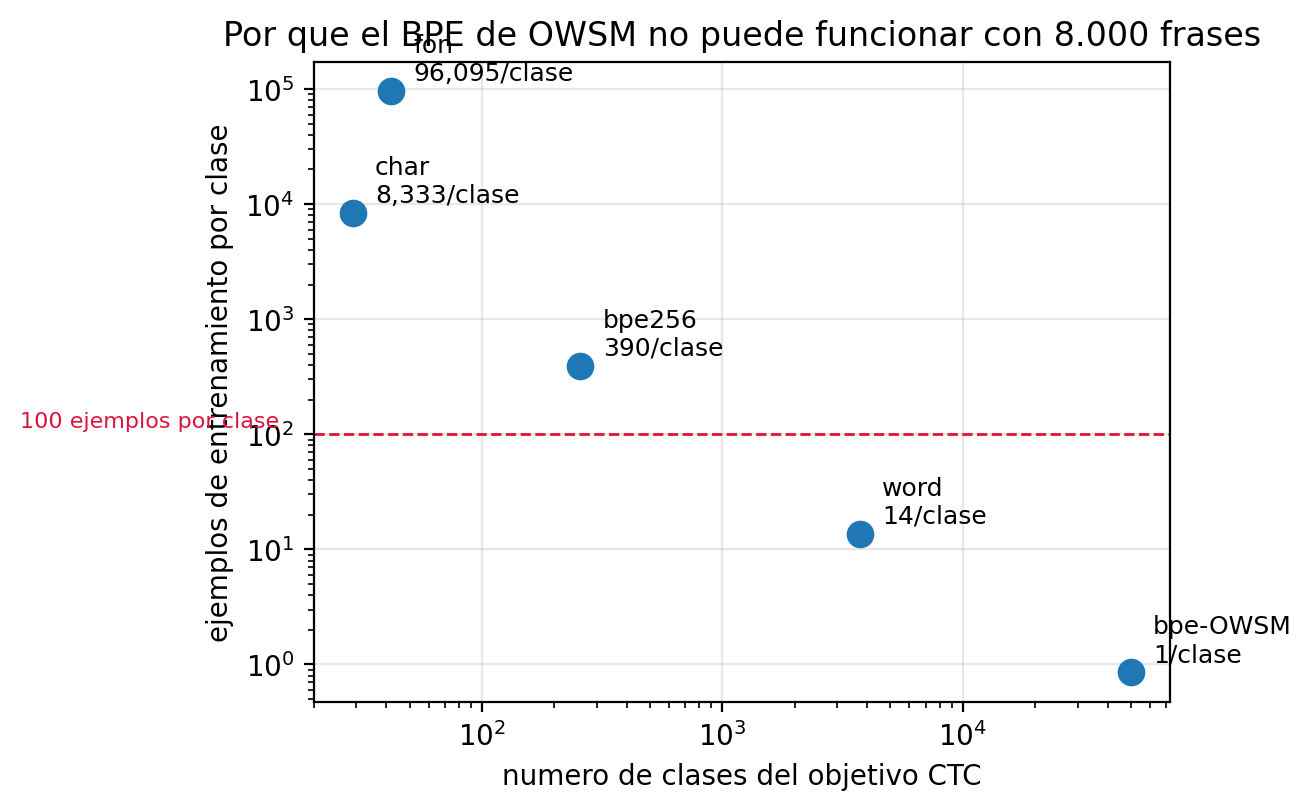


OBJETIVOS LISTOS. Ya puedes lanzar el barrido.


In [12]:
# ══ VERIFICACIONES Y PREPARACION DE OBJETIVOS (ejecutar una vez) ══════
# Usa las 45 sesiones para que los vocabularios sean los definitivos.
_cfg_v = {**DEFAULTS, "n_sessions": 45, "objetivo_ctc": "char", "capa_sesion": True}
_tr, _va, _, _ = get_datos(_cfg_v)
_textos = [_norm(t) for t in _tr.textos()]
print(f"\n{len(_textos)} frases de entrenamiento\n")

# ── 1. inventario de caracteres ───────────────────────────────────────
import collections
_inv = collections.Counter("".join(_textos))
_fuera = {c: n for c, n in _inv.items() if c not in _CHAR2ID}
print("Caracteres distintos en train:", len(_inv))
print("Vocabulario de tokenize_char :", sorted(_CHAR2ID))
if _fuera:
    print(f"\n  *** {sum(_fuera.values())} apariciones de {len(_fuera)} caracteres "
          f"que tokenize_char DESCARTA: {dict(sorted(_fuera.items(), key=lambda x:-x[1])[:15])}")
    print("  *** Si son digitos hay que anadirlos a _CHARS o normalizar el texto,")
    print("  *** porque ahora mismo la REFERENCIA del CER esta incompleta.")
else:
    print("\n  OK: ningun caracter del corpus se pierde.")

# ── 2a. fonemas ───────────────────────────────────────────────────────
_ejemplo = _tr[0]
if _ejemplo.get("fon_ids") is None:
    print("\n[fon] el HDF5 NO trae etiquetas de fonema -> objetivo 'fon' no disponible")
else:
    _maxid = 0
    for i in range(0, len(_tr), max(1, len(_tr)//500)):     # muestra, no todo
        f = _tr[i]["fon_ids"]
        if f is not None and len(f):
            _maxid = max(_maxid, int(f.max()))
    FON_VOCAB = _maxid + 2                       # +1 por el desplazamiento, +1 por el blank
    # Inventario CMU estandar de B2T. Si el numero no cuadra se usan nombres p0..pN
    # y no pasa nada: el modelo trabaja con indices, los nombres son para el log.
    _CMU = ["AA","AE","AH","AO","AW","AY","B","CH","D","DH","EH","ER","EY","F","G",
            "HH","IH","IY","JH","K","L","M","N","NG","OW","OY","P","R","S","SH","T",
            "TH","UH","UW","V","W","Y","Z","ZH","|"]
    FON_NOMBRES = (_CMU if len(_CMU) == FON_VOCAB - 1
                   else [f"p{i}" for i in range(FON_VOCAB - 1)])
    print(f"\n[fon] id maximo={_maxid} -> {FON_VOCAB} clases (blank incluido) · "
          f"nombres {'CMU' if FON_NOMBRES is _CMU else 'genericos'}")
    print("      ejemplo:", _fon_destok(_fon_tok(_ejemplo["fon_ids"])[:14]))

# ── 2b. BPE propio ────────────────────────────────────────────────────
!pip install -q sentencepiece
import sentencepiece as spm, io
for _V in (256,):                                  # anade mas tamanos si quieres
    _mod = io.BytesIO()
    spm.SentencePieceTrainer.train(
        sentence_iterator=iter(_textos), model_writer=_mod,
        vocab_size=_V, model_type="bpe", character_coverage=1.0,
        bos_id=-1, eos_id=-1, unk_id=0, pad_id=-1)
    _sp = spm.SentencePieceProcessor(model_proto=_mod.getvalue())
    _SP[_V] = (_sp, _sp.get_piece_size() + 1)      # +1 por el blank en el indice 0
    print(f"\n[bpe{_V}] {_sp.get_piece_size()} piezas -> {_SP[_V][1]} clases CTC")
    print("      ejemplo:", _sp.encode(_textos[0], out_type=str)[:12])

# ── 2c. palabras ──────────────────────────────────────────────────────
_pal = collections.Counter(w for t in _textos for w in t.split())
WORD2ID = {w: i + 1 for i, w in enumerate(sorted(_pal))}    # 0 = blank
ID2WORD = {i: w for w, i in WORD2ID.items()}
_hapax = sum(1 for w, c in _pal.items() if c == 1)
print(f"\n[word] {len(WORD2ID)} palabras distintas · {sum(_pal.values())} tokens · "
      f"{_hapax} aparecen UNA sola vez ({_hapax/len(_pal)*100:.0f}%)")

# ── 3. figura: ejemplos de entrenamiento por clase ────────────────────
import matplotlib.pyplot as plt
_n_tok = {"char": sum(len(t) for t in _textos),
          "word": sum(_pal.values()),
          f"bpe{256}": sum(len(_SP[256][0].encode(t)) for t in _textos)}
_n_cls = {"char": CHAR_VOCAB, "word": len(WORD2ID) + 1, f"bpe{256}": _SP[256][1]}
if FON_VOCAB:
    _n_cls["fon"] = FON_VOCAB
    _n_tok["fon"] = int(
        np.mean([
            len(_tr[i]["fon_ids"]) if _tr[i]["fon_ids"] is not None else 0
            for i in range(0, len(_tr), max(1, len(_tr) // 200))
        ]) * len(_textos)
    )
_n_cls["bpe-OWSM"] = len(converter.token_list)
_n_tok["bpe-OWSM"] = sum(len(tokenize(t)) for t in _textos[:500]) * len(_textos) // 500

_orden = sorted(_n_cls, key=lambda k: _n_cls[k])
_x = [_n_cls[k] for k in _orden]
_y = [_n_tok[k] / _n_cls[k] for k in _orden]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(_x, _y, s=80, zorder=3)
for k, a, b in zip(_orden, _x, _y):
    ax.annotate(f"{k}\n{b:,.0f}/clase", (a, b), textcoords="offset points",
                xytext=(8, 4), fontsize=9)
ax.axhline(100, ls="--", c="crimson", lw=1)
ax.text(1.2, 115, "100 ejemplos por clase", color="crimson", fontsize=8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("numero de clases del objetivo CTC")
ax.set_ylabel("ejemplos de entrenamiento por clase")
ax.set_title("Por que el BPE de OWSM no puede funcionar con 8.000 frases")
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/objetivos_ejemplos_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"objetivo": _orden, "clases": _x, "tokens_train": [_n_tok[k] for k in _orden],
              "ejemplos_por_clase": [round(v, 1) for v in _y]}) \
  .to_csv(f"{RESULTS_DIR}/objetivos_estadisticas.csv", index=False)
print("\nOBJETIVOS LISTOS. Ya puedes lanzar el barrido.")


## 10c. Auditoría de justicia del bloque B  *(nueva)*

Tres cosas que hay que cerrar antes de comparar unidades de salida, todas CPU.

**El problema serio.** `fon` tiene `texto=False` en `objetivo_info`, así que
`evaluar_ctc_greedy` devuelve `NaN` en CER/WER de texto y solo da un PER. PER y CER
no se comparan: el bloque B daría cuatro números en tres escalas.

**La solución sale de los propios datos.** El separador de palabra (`|`, id 40) está
en el inventario de fonemas, así que alineando separadores con espacios se obtiene un
léxico palabra→pronunciación derivado del corpus, sin CMUdict. Con él, `fonemas_a_texto`
convierte la hipótesis en palabras y `fon` entra en el mismo eje de WER que el resto.
Es un decodificador con léxico básico (distancia de edición, no WFST) — descríbelo así
en la memoria.

**Los otros dos chequeos.** La tasa de OOV de `word` sobre validación es el suelo duro
de su WER, y conviene tenerlo antes de interpretar su fracaso. Y la viabilidad del CTC
(`T ≥ L`): si a un objetivo se le cuelan trials donde las etiquetas superan a los frames,
`zero_infinity=True` anula su pérdida **en silencio** y ese objetivo entrena con menos
ejemplos efectivos que los demás — eso sí rompería la comparación.


In [13]:
# ══════════════════════════════════════════════════════════════════════
# 10c. AUDITORIA DE JUSTICIA DEL BLOQUE B + LEXICO FONEMA->PALABRA
# ══════════════════════════════════════════════════════════════════════
# Ejecutar DESPUES de la celda 10b y ANTES del barrido. Solo CPU.
#   1. Pone los nombres reales de los fonemas (el inventario estandar de B2T).
#   2. Construye el lexico palabra -> pronunciacion alineando el separador de
#      palabra (id 40) con los espacios del texto. Sin esto, el objetivo "fon"
#      da un PER que no se puede comparar con el CER de char/bpe256/word.
#   3. Mide la tasa de OOV de "word" sobre validacion: es el suelo duro de su WER.
#   4. Comprueba la viabilidad del CTC (T >= L) por objetivo. Si a un objetivo se
#      le cuelan trials con L > T, zero_infinity=True anula su perdida EN SILENCIO
#      y ese objetivo entrena con menos ejemplos efectivos que los demas.

import numpy as np, collections

# ── 1. nombres reales de los fonemas ──────────────────────────────────
_B2T_FON = ['BLANK','AA','AE','AH','AO','AW','AY','B','CH','D','DH','EH','ER',
            'EY','F','G','HH','IH','IY','JH','K','L','M','N','NG','OW','OY','P',
            'R','S','SH','T','TH','UH','UW','V','W','Y','Z','ZH','|']
if FON_VOCAB and len(_B2T_FON) == FON_VOCAB - 1:
    FON_NOMBRES = _B2T_FON
    print(f"[fon] inventario B2T reconocido ({len(_B2T_FON)} simbolos)")
    print("      ejemplo:", _fon_destok(_fon_tok(_tr[0]['fon_ids'])))
    print("      texto  :", _norm(_tr[0]['text_raw']))
SEP_FON = _B2T_FON.index('|') + 1 if FON_VOCAB else None    # +1 por el shift

# ── 2. lexico palabra -> pronunciacion, alineando por el separador ────
LEXICO = collections.defaultdict(collections.Counter)
_ok = _malo = 0
for i in range(len(_tr)):
    d = _tr[i]
    if d.get("fon_ids") is None:
        continue
    # (v12) _fon_tok ya quita el relleno; el -1 deshace su shift. Antes se
    # leia fon_ids en crudo y el relleno metia un grupo extra de BLANKs, por
    # eso se descartaba el 100% de las frases.
    ids = list(_fon_tok(d["fon_ids"]) - 1)
    sep = _B2T_FON.index('|')
    grupos, act = [], []
    for x in ids:
        if x == sep:
            if act: grupos.append(tuple(act)); act = []
        else:
            act.append(x)
    if act: grupos.append(tuple(act))
    palabras = _norm(d["text_raw"]).split()
    if len(grupos) == len(palabras):
        _ok += 1
        for w, g in zip(palabras, grupos):
            LEXICO[w][g] += 1
    else:
        _malo += 1
LEXICO = {w: c.most_common(1)[0][0] for w, c in LEXICO.items()}
print(f"\n[lexico] {_ok} frases alineadas, {_malo} descartadas "
      f"({_malo/max(1,_ok+_malo)*100:.1f}%) -> {len(LEXICO)} palabras con pronunciacion")
if LEXICO:
    for w in list(LEXICO)[:4]:
        print(f"         {w:12s} {' '.join(_B2T_FON[p] for p in LEXICO[w])}")

# ── decodificador fonema -> palabras (lexico + distancia de edicion) ──
_LEX_ITEMS = list(LEXICO.items())

def fonemas_a_texto(ids_desplazados):
    """Convierte una hipotesis CTC de fonemas en una cadena de palabras.

    Parte por el separador y mapea cada grupo a la entrada del lexico mas
    cercana en distancia de edicion. Es un decodificador con lexico basico:
    suficiente para poner "fon" en el mismo eje de WER que el resto, y honesto
    de describir en la memoria (no es un WFST).
    """
    orig = [int(x) - 1 for x in ids_desplazados]          # deshace el shift
    sep = _B2T_FON.index('|')
    grupos, act = [], []
    for x in orig:
        if x == sep:
            if act: grupos.append(tuple(act)); act = []
        else:
            act.append(x)
    if act: grupos.append(tuple(act))
    salida = []
    for g in grupos:
        if not g: continue
        mejor, mejor_d = None, 1e9
        for w, pron in _LEX_ITEMS:
            if abs(len(pron) - len(g)) >= mejor_d:        # poda por longitud
                continue
            d = _lev(list(g), list(pron))
            if d < mejor_d:
                mejor, mejor_d = w, d
                if d == 0: break
        if mejor: salida.append(mejor)
    return " ".join(salida)

# ── 3. OOV de "word" sobre validacion = suelo de su WER ───────────────
_v_tok = _v_oov = 0
_frases_con_oov = 0
for i in range(len(_va)):
    ws = _norm(_va[i]["text_raw"]).split()
    n_oov = sum(1 for w in ws if w not in WORD2ID)
    _v_tok += len(ws); _v_oov += n_oov
    _frases_con_oov += (n_oov > 0)
print(f"\n[word] OOV en validacion: {_v_oov}/{_v_tok} tokens "
      f"({_v_oov/_v_tok*100:.1f}%) · {_frases_con_oov}/{len(_va)} frases afectadas "
      f"({_frases_con_oov/len(_va)*100:.0f}%)")
print(f"       -> el modelo de palabras NO PUEDE bajar de {_v_oov/_v_tok*100:.1f}% de WER.")
print("       Es un techo estructural, no un problema de entrenamiento.")

# ── 4. viabilidad del CTC: T (frames tras subsample) >= L (etiquetas) ─
print(f"\n[CTC] viabilidad T>=L por objetivo (muestra de 400 trials, subsample=2)")
_m = range(0, len(_tr), max(1, len(_tr)//400))
_objs = {"char": lambda d: len(tokenize_char(d["text_ctc"])),
         "bpe256": lambda d: len(_SP[256][0].encode(d["text_ctc"])),
         "word": lambda d: len(_word_tok(d["text_ctc"]))}
if FON_VOCAB:
    _objs["fon"] = lambda d: len(_fon_tok(d["fon_ids"]))   # (v12) sin relleno
_fil = []
for nombre, f in _objs.items():
    malos, ratios = 0, []
    for i in _m:
        d = _tr[i]
        T = int(np.ceil(d["input_features"].shape[0] / 2))
        L = f(d)
        ratios.append(T / max(1, L))
        malos += (L > T)
    _fil.append((nombre, np.mean(ratios), min(ratios), malos))
    print(f"   {nombre:8s} T/L medio={np.mean(ratios):5.2f} · minimo={min(ratios):4.2f} · "
          f"{malos} trials con L>T" + ("   <-- PERDIDA ANULADA EN SILENCIO" if malos else ""))
print("\n   Si algun objetivo tiene trials con L>T, zero_infinity=True los anula y ese")
print("   objetivo entrena con menos ejemplos efectivos: la comparacion no seria justa.")
# ── 5. (v12) el relleno de fonemas, comprobado explicitamente ─────────
if FON_VOCAB:
    _crudo = _recort = 0
    _interior = 0
    for i in range(0, len(_tr), max(1, len(_tr) // 300)):
        a = np.asarray(_tr[i]["fon_ids"]).ravel()
        b = _fon_tok(a) - 1
        _crudo += len(a); _recort += len(b)
        _interior += int((b == 0).sum())          # ceros que NO son relleno final
    print(f"\n[fon] relleno: longitud media {_crudo/300:.0f} -> {_recort/300:.0f} "
          f"tras recortar ({100*(1-_recort/_crudo):.0f}% era relleno)")
    if _interior:
        print(f"      AVISO: {_interior} ceros interiores. No son relleno; "
              f"_fon_tok los conserva, pero revisa el inventario.")
    else:
        print("      sin ceros interiores: el recorte es seguro")
    if len(LEXICO) > 1000:
        print(f"      lexico OK ({len(LEXICO)} palabras) -> B1fon dara CER/WER "
              f"comparables, no solo PER")
    else:
        print(f"      LEXICO INSUFICIENTE ({len(LEXICO)} palabras): B1fon solo "
              f"podra reportar PER. Revisa el alineamiento antes de lanzarlo.")

print("\nAUDITORIA COMPLETA.")


[fon] inventario B2T reconocido (41 simbolos)
      ejemplo: B R IH NG | IH T | K L OW S ER |
      texto  : bring it closer

[lexico] 8071 frases alineadas, 1 descartadas (0.0%) -> 3728 palabras con pronunciacion
         bring        B R IH NG
         it           IH T
         closer       K L OW S ER
         my           M AY

[word] OOV en validacion: 589/9445 tokens (6.2%) · 392/1426 frases afectadas (27%)
       -> el modelo de palabras NO PUEDE bajar de 6.2% de WER.
       Es un techo estructural, no un problema de entrenamiento.

[CTC] viabilidad T>=L por objetivo (muestra de 400 trials, subsample=2)
   char     T/L medio=15.14 · minimo=7.02 · 0 trials con L>T
   bpe256   T/L medio=39.01 · minimo=17.20 · 0 trials con L>T
   word     T/L medio=71.32 · minimo=30.20 · 0 trials con L>T
   fon      T/L medio=17.08 · minimo=7.74 · 0 trials con L>T

   Si algun objetivo tiene trials con L>T, zero_infinity=True los anula y ese
   objetivo entrena con menos ejemplos efectivos: la com

## 11. El barrido  *(v10 — cola final)*

Quedan ~3,5 días. Un `COLA_n` por noche, en orden.

| cola | cuándo | runs | horas | qué cierra |
|---|---|---|---|---|
| `COLA_1` | jueves noche | 4 | ~15 | unidad de salida (capítulo entero) |
| `COLA_2` | viernes | 3 | ~14 | días no vistos (capítulo entero) |
| `COLA_3` | sábado | 2 | ~14 | campeón + control del encoder |
| `COLA_4` | domingo | 2 | ~10 | frontend, solo si sobra |

**Lo que ya no se ejecuta.** El bloque D queda como está: el confound de LR
(LoRA a 1e-3 frente a capas descongeladas a 5e-5) se documenta como limitación.
Los cinco puntos de la curva monótona a 30 épocas siguen valiendo a presupuesto
igualado, que es la afirmación que se hace en la memoria. El bloque F se cae
porque `A4randCong` responde casi lo mismo por la mitad de precio.

**Resultados cerrados hasta aquí** (`min_valid_cer_ctc`):

| | CER |
|---|---|
| aleatorio, seeds 7 / 1234 / 2024 | 0.297 / 0.314 / 0.324 |
| OWSM fine-tune completo (v3) | 0.381 |
| OWSM congelado, 70 ép. | 0.440 |
| OWSM `els=0.2` | 0.689 |
| aleatorio `els=1.0` | 0.854 (diverge) |

Desviación entre semillas ≈ 0,012; IC95 de evaluación ±0,007.


In [15]:
# ══════════════════════════════════════════════════════════════════════
# BARRIDO v7 — reordenado tras el resultado del bloque A
# ══════════════════════════════════════════════════════════════════════
# LO QUE CAMBIO. El bloque A dio la vuelta a la tesis del TFG:
#
#   min_valid_cer_ctc (interno de ESPnet, val completo, comparable entre runs)
#     A1randEls   init ALEATORIO, fine-tune completo   0.324 @ep28   6.6 CU
#     v5          init OWSM,      fine-tune completo   0.362 @ep60  15.2 CU
#     v3          init OWSM,      fine-tune completo   0.381 @ep37   8.9 CU
#     A2congelado init OWSM,      encoder CONGELADO    0.658 @ep29   6.3 CU
#     A1randLr1   init ALEATORIO, els=1.0              0.854  DIVERGE
#
# El preentrenamiento de OWSM no transfiere: un encoder identico inicializado
# al azar converge antes, llega mas abajo y cuesta la mitad. La comparacion es
# limpia (A1 y v3 comparten receta exacta; la unica variable es la init).
#
# CONSECUENCIAS PARA EL PLAN:
#   - La RECETA base pasa a ser la de A1randEls (aleatorio). Es mejor Y mas
#     barata, asi que los bloques que quedan salen mas baratos de lo previsto.
#   - El bloque D deja de ser un extra y pasa a ser la figura central: rellena
#     la curva monotona "cuanto mas de OWSM conservas, peor vas".
#   - Aparece una pregunta nueva e inevitable: si los pesos no importan,
#     ¿importa el tamano? -> bloque F, encoder recortado.

RECETA = dict(
    n_sessions=45, max_epoch=40, warmup=1500,   # v9: 30 era corto, H1
                                                # seguia bajando en la 40
    frontend="deep", deep_dim=512, deep_bloques=2, subsample=2,
    interctc_weight=0.3, interctc_layers=(2,),
    objetivo_ctc="char", ctc_weight=1.0, capa_sesion=True,
    norm="ninguna", usar_lora=False,
    init_encoder="random",               # <-- v7: el nuevo punto de partida
    batch_size=16, accum_grad=2,
    lr=1e-3, enc_lr_scale=0.05,
    optim="adamw", weight_decay=1e-2, grad_clip=100.0,
    patience=None,
    aug=True, aug_ruido=0.5, aug_offset=0.2,
    aug_n_tiempo=2, aug_max_tiempo=0.05,
    aug_n_canales=2, aug_max_canales=20,
    suavizado=0.0, seed=2024,
)
R = lambda **kw: {**RECETA, **kw}
OWSM = lambda **kw: {**RECETA, "init_encoder": "owsm", **kw}


# ══ BLOQUE A4 — EL CONTROL QUE FALTA (~5 h) ══════════════════════════
# PRIORIDAD MAXIMA. El frontend + capa de sesion + cabeza CTC son 16.2M params,
# el 39% del modelo, y entrenan a 1e-3 mientras el encoder va a 5e-5. Surge la
# pregunta: ¿cuanto esta haciendo el encoder? Encoder ALEATORIO y CONGELADO es
# el espejo de A2 (OWSM congelado = 0.440) y separa "los pesos del encoder
# importan" de "entrenar el encoder importa".
#   ~0.44 -> las features de OWSM no valen mas que las aleatorias
#   ~0.30 -> el encoder es irrelevante, todo lo hace el frontend
#   ~0.80 -> OWSM congelado si aporta; la ventaja del azar aparece al entrenar
BLOQUE_A4 = [
    R(nombre="A4randCong", unfreeze_encoder=False),
]

# ══ BLOQUE D — cierre del confound de LR (~10 h) ══════════════════════
# Resultados a 30 epocas (min_valid_cer_ctc), encoder entero a 5e-5:
#     0 de 6 capas (congelado)   16.2M   0.658   (a 70 ep converge en 0.440)
#     ultimas 2 de 6             24.6M   0.521   (bajando -0.012/ep)
#     ultimas 4 de 6             33.0M   0.493   (bajando -0.007/ep)
#     las 6, init OWSM (v3)      41.4M   0.381
#     las 6, init aleatorio      41.4M   0.324
#   Monotona: cuantas mas capas pueden alejarse de OWSM, mejor.
#
# EL CONFOUND. set_encoder_lr_scale mete los parametros LoRA en el grupo
# "nuevos" ("lora_" in name) con base_lr=1e-3, y las capas descongeladas de
# D2/D3 en "preentrenados" con base_lr*0.05=5e-5. Factor 20. Asi que
# "LoRA (0.403) gana a descongelar 4 capas (0.493)" es indistinguible de
# "1e-3 gana a 5e-5". Estas dos runs lo cierran con el LR igualado.
BLOQUE_D = [
    OWSM(nombre="D2bUlt2Lr1", unfreeze_ultimas=2, enc_lr_scale=1.0),
    OWSM(nombre="D3bUlt4Lr1", unfreeze_ultimas=4, enc_lr_scale=1.0),
]
# AVISO: H3 mostro que OWSM con els=0.2 se hunde (0.689) y A1randLr1 divergio
# con els=1.0. Aqui son solo 2-4 capas, otro regimen, pero MIRA LA EPOCA 5:
# si valid_cer_ctc sigue >0.9 y train_loss_ctc esta clavado, corta y usa
# enc_lr_scale=0.2. Si tambien se hunde, ESE es el resultado: la ventaja de
# LoRA es que puede adaptar todas las capas sin desestabilizarlas.

# ══ BLOQUE H — HECHO ══════════════════════════════════════════════════
# Semillas (init aleatorio, 40 epocas, min_valid_cer_ctc):
#     seed 7    0.297      seed 1234  0.314      seed 2024 (A1, 30 ep) 0.324
#   Desviacion entre semillas ~0.012, frente al IC95 de evaluacion de +-0.007:
#   la incertidumbre que manda es la de semilla, no la del tamano del val.
#   La distancia a v3 (0.381) son 5-7 desviaciones: el hallazgo aguanta.
#
# H3owsmEls02 (OWSM, els=0.2, 40 ep): 0.689 frente a 0.381 con els=0.05.
#   Subirle el LR a OWSM no lo salva, lo hunde. Pero ojo al patron completo:
#     aleatorio els=0.05  0.297-0.324   |   aleatorio els=1.0   0.854 (diverge)
#     OWSM      els=0.05  0.381         |   OWSM      els=0.2   0.689
#   LOS DOS INITS NECESITAN EL LR BAJO. enc_lr_scale=0.05 no esta protegiendo
#   pesos preentrenados: es estabilidad de optimizacion de esta arquitectura.
#   Hay que reescribir esa justificacion en la metodologia.

# ══ BLOQUE F — ¿IMPORTA EL TAMANO? (~7 h) ═════════════════════════════
# Si los pesos no aportan, ¿aporta la arquitectura de 6 bloques? Solo tiene
# sentido con init aleatorio. Da el eje coste-eficiencia del TFG.
BLOQUE_F = [
    R(nombre="F1L3", n_capas_encoder=3),
    R(nombre="F2L2", n_capas_encoder=2, interctc_layers=(1,)),
]

# ══ BLOQUE B — UNIDAD DE SALIDA (~13 h) ═══════════════════════════════
# Intacto en valor: "a que granularidad se lee la corteza" es independiente de
# la pregunta de OWSM. Ahora sobre base aleatoria, que es mejor y mas barata.
# char ya lo tienes: A1randEls = 0.324.
# OJO: CER, PER y WER no son comparables. El eje comun es el WER final.
# (v12) LOS CUATRO A 40 EPOCAS. B2bpe256 ya corrio 40 y SKIP_IF_DONE lo
# saltara solo. B3/B4 corrieron 20 porque se daban por perdidos: cambiar
# max_epoch cambia el tag, asi que se reentrenan desde cero (~5,1 h cada uno).
#
# LEE ESTO ANTES DE GASTAR 10 HORAS EN B3 Y B4. Sus resultados a 20 epocas ya
# son los mejores del barrido (CER 0.240 y 0.247 frente a 0.279+-0.011 de char)
# y la pendiente en la epoca 19 seguia en -0.007/ep, diez veces la del char
# convergido. O sea: ganaron con la MITAD de presupuesto y sin converger. Eso
# es mas fuerte que empatar el presupuesto, no mas debil. Si vas justo de
# tiempo, deja B3 y B4 como estan y escribe en la memoria la frase de arriba
# citando la columna pendiente_cer_ctc. El unico que hay que relanzar si o si
# es B1fon, porque el actual no es un resultado: es el bug del relleno.
BLOQUE_B = [
    R(nombre="B1fon",    objetivo_ctc="fon"),                    # OBLIGATORIO
    R(nombre="B2bpe256", objetivo_ctc="bpe256", bpe_vocab=256),  # ya hecho, se salta
    R(nombre="B3word",   objetivo_ctc="word"),                   # opcional: 20 -> 40
    R(nombre="B4bpe50k", objetivo_ctc="bpe"),                    # opcional: 20 -> 40
]

# Lo minimo que cierra la memoria, en orden. ~14 h.
BLOQUE_B_MINIMO = [
    R(nombre="B1fon", objetivo_ctc="fon"),
]

# ══ BLOQUE E — DIAS NO VISTOS (~11 h) ═════════════════════════════════
BLOQUE_E = [
    R(nombre="E1hoIdent",  holdout_sesiones=5, holdout_capa_sesion="identidad"),
    R(nombre="E2hoMedia",  holdout_sesiones=5, holdout_capa_sesion="media"),
    R(nombre="E3hoSinSes", holdout_sesiones=5, capa_sesion=False),
]

# ══ BLOQUE C — FRONTEND (~8 h) ════════════════════════════════════════
# Baja de prioridad: con el encoder al azar, el frontend y la receta son ya lo
# unico que queda, asi que esta comparacion es menos discriminante que antes.
# Si el tiempo aprieta, este es el bloque que se recorta.
BLOQUE_C = [
    R(nombre="C1linear", frontend="linear"),
    R(nombre="C2conv1d", frontend="conv1d"),
]

# ══ BLOQUE G — CAMPEON (~10 h) ════════════════════════════════════════
# A1 tocaba su minimo en la epoca 28 de 30: no habia terminado. Con 70 epocas
# y early stopping se ve hasta donde llega de verdad.
BLOQUE_G = [
    R(nombre="G1campeon", max_epoch=70, patience=15, patience_start_epoch=25),
]


# ══════════════════════════════════════════════════════════════════════
# COLA — quedan ~3.5 dias. Ejecuta en este orden, uno por noche.
# ══════════════════════════════════════════════════════════════════════
#   COLA_1  jueves noche  4 runs  ~15 h   unidad de salida   <- capitulo entero
#   COLA_2  viernes       3 runs  ~14 h   dias no vistos     <- capitulo entero
#   COLA_3  sabado        2 runs  ~14 h   campeon + control
#   COLA_4  domingo       2 runs  ~10 h   solo si sobra tiempo
#
# Lo que NO se ejecuta y se reporta como esta:
#   - Bloque D: el confound de LR (LoRA a 1e-3 frente a capas descongeladas a
#     5e-5) se documenta en la memoria como limitacion. Los cinco puntos de la
#     curva monotona a 30 epocas siguen siendo validos a presupuesto igualado.
#   - Bloque F (tamano del encoder): A4randCong responde casi lo mismo mas barato.

COLA_1 = BLOQUE_B      # fon · bpe256 · word · bpe50k
COLA_2 = BLOQUE_E  + BLOQUE_A4 + BLOQUE_C    # holdout identidad · media · sin capa de sesion
COLA_3 = BLOQUE_F + BLOQUE_D
COLA_4 = BLOQUE_C      # frontend linear · conv1d
# ALTERNATIVA a COLA_4, mas valiosa: POWSM (espnet/powsm) es OWSM reentrenado
# para fonemas. La conclusion "el preentrenamiento no transfiere" se apoya hoy
# en UN solo modelo; POWSM es el mejor contraste porque es fonetico, o sea mas
# cercano a lo que codifica la corteza motora. Requiere anadir
# init_encoder="powsm" y, sobre todo, IMPRIMIR CUANTOS TENSORES SE CARGAN:
# load_state_dict(strict=False) ignora en silencio las claves que no encajan y
# te deja con init aleatorio creyendo que tienes POWSM.

# ══ COLA FINAL (v12) ══════════════════════════════════════════════════
#   COLA_5  ~14 h  B1fon arreglado + campeon   <- lo imprescindible
#   COLA_6  ~10 h  B3word y B4bpe50k a 40 ep   <- solo si sobra tiempo
COLA_5 = BLOQUE_B_MINIMO + BLOQUE_G
COLA_6 = [R(nombre="B3word", objetivo_ctc="word"),
          R(nombre="B4bpe50k", objetivo_ctc="bpe")]

BARRIDO = COLA_3

def estimar_min(cfg):
    c = {**DEFAULTS, **cfg}
    factor = 1.0 if "L4" in GPU_NAME else (2.0 if "T4" in GPU_NAME else 0.5)
    por_epoca = 7.72 * (c["n_sessions"] / 45)          # medido: A1 231.6 min/30 ep
    if c["frontend"] != "deep":      por_epoca *= 0.75
    if not c["unfreeze_encoder"]:    por_epoca *= 0.95
    if c.get("n_capas_encoder"):     por_epoca *= (0.45 + 0.55*c["n_capas_encoder"]/6)
    if c.get("holdout_sesiones"):    por_epoca *= 0.9
    return c["max_epoch"] * por_epoca * factor

print(f"GPU: {GPU_NAME} ({CU_H} unidades/h)")
print(f"{len(BARRIDO)} experimentos · ~{sum(estimar_min(e) for e in BARRIDO)/60:.1f} h · "
      f"~{CU_H*sum(estimar_min(e) for e in BARRIDO)/60:.1f} compute units\n")
for e in BARRIDO:
    print(f"  ~{estimar_min(e)/60:4.1f} h · {hacer_tag({**DEFAULTS, **e})}")

print("\n── cola restante ──")
_t = 0
for _n, _b in [("COLA_1 unidad salida", COLA_1), ("COLA_2 dias no vistos", COLA_2),
               ("COLA_3 campeon+control", COLA_3), ("COLA_4 frontend", COLA_4)]:
    _h = sum(estimar_min(e) for e in _b)/60; _t += _h
    print(f"  {_n:24s} {len(_b)} runs  {_h:5.1f} h  {CU_H*_h:5.0f} CU")
print(f"  {'TOTAL':24s} {sum(len(b) for b in [COLA_1,COLA_2,COLA_3,COLA_4])} runs "
      f" {_t:5.1f} h  {CU_H*_t:5.0f} CU")


GPU: NVIDIA L4 (1.71 unidades/h)
4 experimentos · ~17.3 h · ~29.6 compute units

  ~ 3.7 h · F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess_ep40_s2024_0fbdf3
  ~ 3.3 h · F2L2_n45_deep_d512b2s2_char_initrandom_L2_sess_ep40_s2024_d6b3e1
  ~ 5.1 h · D2bUlt2Lr1_n45_deep_d512b2s2_char_unf2ult_sess_ep40_s2024_15113f
  ~ 5.1 h · D3bUlt4Lr1_n45_deep_d512b2s2_char_unf4ult_sess_ep40_s2024_40ae97

── cola restante ──
  COLA_1 unidad salida     4 runs   20.6 h     35 CU
  COLA_2 dias no vistos    6 runs   26.5 h     45 CU
  COLA_3 campeon+control   4 runs   17.3 h     30 CU
  COLA_4 frontend          2 runs    7.7 h     13 CU
  TOTAL                    16 runs   72.1 h    123 CU


## 12. Ejecutar

Con Colab Pro+ puedes activar la ejecución en segundo plano y cerrar el navegador. Si te desconectan a mitad, vuelve a lanzar esta celda: los experimentos terminados se saltan y el que estuviera a medias reanuda desde su `checkpoint.pth`.

In [17]:
inicio = time.time()
for cambios in BARRIDO:
    run_experiment(cambios)

print("=" * 78)
print(f"BARRIDO COMPLETO en {(time.time()-inicio)/60:.0f} min "
      f"(~{CU_H*(time.time()-inicio)/3600:.1f} compute units)")
print("Resultados en:", CSV_RESULTADOS)

[EXPERIMENTO] F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess_ep40_s2024_0fbdf3
  batch=16 · ~504 pasos/epoca · warmup 1500 (~3.0 epocas)
  recopilando estadisticas (solo la primera vez por configuracion de datos)...
  [v7] encoder recortado a 3 bloques (interctc en [2])


/usr/bin/python3 /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-8910cb4b-9226-4ac5-b9ff-3d9644dbc770.json


  [control] encoder con inicializacion ALEATORIA (sin pesos de OWSM)
  encoder: encoder entero (3 capas)
  init=random
  frontend=deep + capa_sesion(45) · objetivo_ctc=char(29) · lora=False · encoder=descongelado · ctc_weight=1.0 · norm=ninguna
  28,801,821 entrenables / 28,801,821 totales (100.00%)
  [nota] ctc_weight=1 -> ESPnet desactiva el decoder (solo CTC; la evaluacion sera greedy)
  LR diferencial: 22 tensores a 0.001 · 116 a 5e-05
  collect_stats OK


/usr/bin/python3 /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-8910cb4b-9226-4ac5-b9ff-3d9644dbc770.json


  [v7] encoder recortado a 3 bloques (interctc en [2])


...

  evaluando con CTC greedy...


/usr/local/lib/python3.13/dist-packages/espnet2/s2t/espnet_model.py:338: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(False):


    [ctc] REF: you can see the code at this point as well
    [ctc] HYP: t o a a o e e
    [ctc] REF: how does it keep the cost down
    [ctc] HYP: t a a a  a
    [ctc] REF: not too controversial
    [ctc] HYP: t a o 
    por trial: mediana=0.778 p10=0.700 p90=0.852 · 0% por debajo de 0.2
    n=1426 · SE=0.0016 · IC95=±0.0031  (dos runs con CERs que difieran menos que la suma de sus IC95 no se pueden distinguir con esta n)
  [CTC greedy] cer_ctc(micro, comparable con el log)=0.776 · CER texto=0.777 · WER texto=1.033
  (objetivo char: la cabeza CTC y el decoder usan vocabularios distintos, el beam search hibrido no aplica)
  checkpoint guardado en Drive: valid.cer_ctc.best.pth


/tmp/ipykernel_16821/4171631692.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([pd.read_csv(CSV_RESULTADOS), df_nueva], ignore_index=True)


  hecho en 301.8 min (~8.60 compute units)

BARRIDO COMPLETO en 1151 min (~32.8 compute units)
Resultados en: /content/drive/MyDrive/TFG/resultados/resultados.csv


## 13. Modelo de lenguaje sobre la salida CTC

Hasta aquí todas las métricas salen de **CTC greedy**: el carácter más probable en cada instante, sin nada detrás. Es la medida honesta de cuánto extrae el encoder de la señal, y por eso fue la correcta durante el diagnóstico. Pero produce texto como `you cat se to good at this pute is wee`, con palabras que no existen.

Esta sección añade la pieza que falta y que usa toda la literatura de brain-to-text: una **búsqueda en haz con un modelo de lenguaje de n-gramas**, que reordena las hipótesis del CTC favoreciendo secuencias de palabras reales.

Dos avisos importantes:

- **El n-grama se entrena SOLO con las transcripciones de entrenamiento.** Usar las de validación sería una fuga de datos que inflaría el resultado. El código lo construye desde `train_raw` y nunca toca `val_raw`.
- **Esto no mejora la lectura del cerebro, mejora la escritura.** En la memoria conviene reportar las dos cifras por separado: el CER greedy mide el encoder, el WER con LM mide el sistema completo. Mezclarlas oculta cuánto viene de cada parte.

**Sobre el suavizado del n-grama.** La versión anterior generaba el ARPA con *add-k* en Python puro, porque el `kenlm` de pip trae solo el lector y no `lmplz`. Ahora la celda 0 compila kenlm desde fuente, así que `lmplz` está disponible y el ARPA se estima con **Kneser-Ney**, que es lo estándar. Importa para la conclusión: con add-k, un trigrama disperso se penaliza el doble que un bigrama, así que el resultado de que *el trigrama va peor* mezclaba el orden del modelo con el suavizado. Con KN la comparación queda limpia, cambie de signo o no. Si `lmplz` no llegó a compilar, `construir_arpa` cae automáticamente al add-k anterior y lo dice por pantalla: apunta cuál de los dos usaste.

In [18]:
# ══════════════════════════════════════════════════════════════════════
# (v6.1) AQUI YA NO SE INSTALA NADA. kenlm y pyctcdecode se instalan en la
# celda 0, antes del unico reinicio de la sesion.
#
# Motivo: instalar a mitad de sesion cambia numpy en disco mientras el
# kernel lo tiene cargado. A partir de ahi scipy falla con "All ufuncs must
# have type numpy.ufunc" y hay que reiniciar y reejecutar el notebook
# entero. Despues de un barrido de 11 horas eso duele de verdad; los
# checkpoints estan en Drive, pero se pierde el estado de la sesion.
# ══════════════════════════════════════════════════════════════════════
import math, collections, shutil, subprocess

try:
    import kenlm
    from pyctcdecode import build_ctcdecoder
except ImportError as _e:
    raise ImportError(
        f"Falta {_e.name}. Se instala en la celda 0 (seccion 0. Instalacion), "
        "no aqui. Ejecuta esa celda, reinicia el entorno y vuelve a recorrer "
        "el notebook desde la celda 1.") from None

from itertools import groupby

# lmplz solo existe si la celda 0 lo compilo; si no, se usa el add-k.
LMPLZ = "/content/kenlm/build/bin/lmplz"
HAY_LMPLZ = os.path.exists(LMPLZ)
print(f"Estimador de n-gramas: {'Kneser-Ney (lmplz)' if HAY_LMPLZ else 'add-k en Python puro'}")


def _vocab_de_arpa(ruta):
    """Palabras del bloque \\1-grams:. pyctcdecode quiere PALABRAS, no <s>/<unk>."""
    vocab, dentro = [], False
    with open(ruta) as f:
        for linea in f:
            if linea.startswith("\\1-grams:"):
                dentro = True
                continue
            if dentro:
                if linea.startswith("\\") or not linea.strip():
                    break
                w = linea.split("\t")[1].strip()
                if not w.startswith("<"):
                    vocab.append(w)
    return vocab


def construir_arpa_kn(frases, ruta, orden=2):
    """ARPA con Kneser-Ney interpolado, via lmplz."""
    txt = ruta + ".txt"
    with open(txt, "w") as f:
        f.write("\n".join(frases) + "\n")
    # --discount_fallback es obligatorio aqui: KN necesita estadisticas de
    # n-gramas que con ~8.000 frases no existen, y lmplz aborta sin el.
    subprocess.run([LMPLZ, "-o", str(orden), "--discount_fallback",
                    "--text", txt, "--arpa", ruta],
                   check=True, capture_output=True, text=True)
    return ruta, _vocab_de_arpa(ruta)


def construir_arpa_addk(frases, ruta, orden=2, k=0.4):
    """Respaldo si lmplz no compilo: add-k con backoff, en Python puro.

    No es Kneser-Ney. Penaliza de mas los ordenes altos, asi que una
    comparacion bigrama/trigrama hecha con esto no es concluyente.
    """
    N = orden
    cnt = {i: collections.Counter() for i in range(1, N + 1)}
    for f in frases:
        ws = ["<s>"] * (N - 1) + f.split() + ["</s>"]
        cnt[1].update(ws[N - 1:])                      # sin el relleno inicial
        for i in range(2, N + 1):
            cnt[i].update(tuple(ws[j:j + i]) for j in range(len(ws) - i + 1))

    vocab = sorted(cnt[1])
    V, tot = len(vocab) + 1, sum(cnt[1].values())      # +1 por <unk>
    p_unk = k / (tot + k * V)
    p = {1: {(w,): (cnt[1][w] + k) / (tot + k * V) for w in cnt[1]}}

    bo = {}
    for i in range(2, N + 1):
        ctx = collections.Counter()
        for g, c in cnt[i].items():
            ctx[g[:-1]] += c
        p[i] = {g: (c + k) / (ctx[g[:-1]] + k * V) for g, c in cnt[i].items()}
        num, den = collections.defaultdict(float), collections.defaultdict(float)
        for g in cnt[i]:
            num[g[:-1]] += p[i][g]
            den[g[:-1]] += p[i - 1].get(g[1:], p_unk)  # el mismo n-grama sin la cabeza
        for h in ctx:
            rb, ru = 1.0 - num[h], 1.0 - den[h]
            bo[h] = (rb / ru) if rb > 1e-9 and ru > 1e-9 else 1e-9

    lg = lambda x: math.log10(max(x, 1e-12))
    with open(ruta, "w") as f:
        f.write("\\data\\\n")
        f.write(f"ngram 1={len(vocab) + 2}\n")
        for i in range(2, N + 1):
            f.write(f"ngram {i}={len(p[i])}\n")

        f.write("\n\\1-grams:\n")
        f.write(f"{lg(p_unk):.6f}\t<unk>\n")
        f.write(f"-99\t<s>\t{lg(bo.get(('<s>',), 1.0)):.6f}\n")
        for w in vocab:
            b = bo.get((w,))
            f.write(f"{lg(p[1][(w,)]):.6f}\t{w}" + (f"\t{lg(b):.6f}" if b else "") + "\n")

        for i in range(2, N + 1):
            f.write(f"\n\\{i}-grams:\n")
            for g, pr in p[i].items():
                # convencion ARPA: un n-grama que predice <s> lleva -99
                col = "-99" if g[-1] == "<s>" else f"{lg(pr):.6f}"
                b = bo.get(g) if i < N else None
                f.write(f"{col}\t{' '.join(g)}" + (f"\t{lg(b):.6f}" if b else "") + "\n")
        f.write("\n\\end\\\n")

    return ruta, [w for w in vocab if not w.startswith("<")]


def construir_arpa(frases, ruta, orden=2, k=0.4):
    """Kneser-Ney si lmplz esta, add-k si no. Misma firma que antes."""
    if HAY_LMPLZ:
        return construir_arpa_kn(frases, ruta, orden=orden)
    return construir_arpa_addk(frases, ruta, orden=orden, k=k)


def localizar_exp(tag):
    """El .pth puede estar en /content/exp (misma sesion) o en Drive (GUARDAR_CKPT)."""
    for base in (OUTPUT_DIR, RESULTS_DIR):
        d = os.path.join(base, tag)
        if os.path.isdir(d) and glob.glob(os.path.join(d, "*.pth")):
            return d
    raise FileNotFoundError(
        f"No encuentro ningun .pth de '{tag}' ni en {OUTPUT_DIR} ni en {RESULTS_DIR}. "
        f"Si la VM se reinicio y GUARDAR_CKPT estaba en False, el modelo se perdio.")


def _barra(i, n, etiqueta, cada=None):
    cada = cada or max(1, n // 10)
    if (i + 1) % cada == 0 or i + 1 == n:
        print(f"\r    {etiqueta}: {i + 1}/{n}", end="" if i + 1 < n else "\n", flush=True)


@torch.no_grad()
def logprobs_val(cfg, exp_dir, n=None):
    """Log-probabilidades CTC de la validacion, calculadas UNA sola vez.

    n=None -> los 1.426 trials. Ocupan poco (unos 35 KB por trial) y asi el
    barrido de alpha/beta y el oraculo no vuelven a tocar la GPU.
    """
    _, val_raw, _, n_ses = get_datos(cfg)
    modelo = cargar_modelo_entrenado(cfg, exp_dir, n_ses)
    n = len(val_raw) if n is None else min(n, len(val_raw))
    idxs = np.linspace(0, len(val_raw) - 1, n).astype(int)

    lps, refs = [], []
    for j, i in enumerate(idxs):
        d = val_raw[int(i)]
        x = preparar_speech(d, cfg)
        sp = torch.tensor(x, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        ln = torch.tensor([sp.shape[1]], dtype=torch.long, device=DEVICE)
        enc, _ = modelo.encode(sp, ln)
        if isinstance(enc, tuple):
            enc = enc[0]
        # pyctcdecode espera log-probabilidades normalizadas en (T, V)
        lps.append(torch.log_softmax(modelo.ctc.ctc_lo(enc)[0].float(), -1).cpu().numpy())
        refs.append(d["text_raw"])
        _barra(j, n, "codificando")
    del modelo
    gc.collect(); torch.cuda.empty_cache()
    return lps, refs


def greedy_desde_lp(lp, blank=CHAR_BLANK_ID):
    """El MISMO greedy que evaluar_ctc_greedy: argmax + colapso + quitar blanks.

    Con pyctcdecode y beam_width=1 el resultado no es identico, y entonces las
    cifras no cuadrarian con la columna cer_ctc_greedy de resultados.csv.
    """
    ids = lp.argmax(-1).tolist()
    return destok_char([k for k, _ in groupby(ids) if k != blank])


def frases_entrenamiento(cfg):
    """Transcripciones de TRAIN normalizadas (nunca las de validacion: seria fuga)."""
    train_raw, _, _, _ = get_datos(cfg)
    return [_norm(t) for t in train_raw.textos()]


def wer_oraculo(dec_sin_lm, lps, refs, beam=100):
    """Cota inferior: el mejor WER alcanzable eligiendo dentro del beam acustico.

    Se usa el decodificador SIN modelo de lenguaje a proposito. Asi el beam
    contiene las hipotesis que propone el encoder por si solo, y el oraculo
    responde a: si tuviera un LM perfecto para reordenar esa lista, hasta donde
    llegaria. La diferencia entre oraculo y LM real es el margen que queda en el
    LM; la diferencia entre oraculo y cero es lo que le falta al encoder.
    """
    cer_o = wer_o = 0.0
    n_hip = 0
    for i, (lp, r) in enumerate(zip(lps, refs)):
        # pyctcdecode poda por defecto con token_min_logp=-5 y beam_prune_logp=-10.
        # Para un oraculo eso es demasiado estricto: interesa la lista mas amplia
        # que el encoder considere plausible, no la mas limpia.
        hips = [h[0] for h in dec_sin_lm.decode_beams(
            lp, beam_width=beam, token_min_logp=-8.0, beam_prune_logp=-20.0)]
        n_hip += len(hips)
        wers = [wer(r, h) for h in hips]
        j = int(np.argmin(wers))
        wer_o += wers[j]
        cer_o += cer(r, hips[j])
        _barra(i, len(lps), "oraculo")
    n = len(lps)
    return cer_o / n, wer_o / n, n_hip / n


def evaluar_con_lm(cfg, tag, ordenes=(2, 3), n=None, n_barrido=200,
                   alphas=(0.3, 0.6, 1.0), betas=(0.0, 1.5, 3.0),
                   beam=100, mostrar=3):
    """greedy vs. n-grama (bigrama y trigrama) vs. oraculo, sobre los mismos trials.

    alpha y beta se eligen sobre los primeros n_barrido trials y el numero final
    se da sobre los n trials completos. Ambos salen de validacion: hay que
    decirlo en la memoria, no hay test ciego todavia.
    """
    assert cfg["objetivo_ctc"] == "char", "el decodificador con LM asume objetivo char"
    exp_dir = localizar_exp(tag)
    print(f"Experimento: {exp_dir}\n")

    frases = frases_entrenamiento(cfg)
    lps, refs = logprobs_val(cfg, exp_dir, n=n)
    n = len(refs)
    labels = [""] + _CHARS                     # indice 0 = blank, igual que la cabeza CTC
    print(f"  {n} trials de validacion · LM sobre {len(frases)} frases de train\n")

    def medir(hips):
        return (float(np.mean([cer(r, h) for r, h in zip(refs, hips)])),
                float(np.mean([wer(r, h) for r, h in zip(refs, hips)])))

    filas = []
    cer_g, wer_g = medir([greedy_desde_lp(lp) for lp in lps])
    filas.append(("greedy", "", "", cer_g, wer_g))
    print(f"  greedy: CER {cer_g:.3f} · WER {wer_g:.3f}")

    hips_por_orden = {}
    for orden in ordenes:
        ruta, vocab = construir_arpa(frases, f"/content/lm{orden}.arpa", orden=orden)
        print(f"\n  {orden}-grama · {len(vocab)} palabras · "
              f"ARPA {os.path.getsize(ruta) / 1e6:.1f} MB")
        mejor = None
        for a in alphas:
            for b in betas:
                dec = build_ctcdecoder(labels, kenlm_model_path=ruta,
                                       unigrams=vocab, alpha=a, beta=b)
                sub = slice(0, min(n_barrido, n))
                hs = [dec.decode(lp, beam_width=beam) for lp in lps[sub]]
                w = float(np.mean([wer(r, h) for r, h in zip(refs[sub], hs)]))
                print(f"    alpha={a:<4} beta={b:<4} WER={w:.3f}  (n={min(n_barrido, n)})")
                if mejor is None or w < mejor[0]:
                    mejor = (w, a, b, dec)
        _, a, b, dec = mejor
        hips = []
        for i, lp in enumerate(lps):
            hips.append(dec.decode(lp, beam_width=beam))
            _barra(i, n, f"{orden}-grama final")
        c, w = medir(hips)
        hips_por_orden[orden] = hips
        filas.append((f"{orden}-grama", a, b, c, w))
        print(f"  {orden}-grama: CER {c:.3f} · WER {w:.3f}  (alpha={a}, beta={b})")

    dec_sin = build_ctcdecoder(labels)          # sin LM: el beam puramente acustico
    cer_o, wer_o, hip_medias = wer_oraculo(dec_sin, lps, refs, beam=beam)
    filas.append(("oraculo", "", "", cer_o, wer_o))
    print(f"  oraculo: CER {cer_o:.3f} · WER {wer_o:.3f}  "
          f"({hip_medias:.0f} hipotesis por trial de media)")

    print(f"\n  {'':12s} {'CER':>8} {'WER':>8}   ({n} trials)")
    for nom, a, b, c, w in filas:
        extra = f"   alpha={a}, beta={b}" if a != "" else ""
        print(f"  {nom:12s} {c:8.3f} {w:8.3f}{extra}")

    for k in range(mostrar):
        print(f"\n  REF    : {_norm(refs[k])}")
        print(f"  greedy : {greedy_desde_lp(lps[k])}")
        for orden in ordenes:
            print(f"  {orden}-grama: {hips_por_orden[orden][k]}")

    tabla = pd.DataFrame(filas, columns=["metodo", "alpha", "beta", "cer", "wer"])
    tabla.insert(0, "exp_tag", tag)
    tabla["n_trials"] = n
    destino = f"{RESULTS_DIR}/{tag}/lm_resultados.csv"
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    tabla.to_csv(destino, index=False)
    print(f"\n  guardado en {destino}")
    return tabla

Estimador de n-gramas: Kneser-Ney (lmplz)


### Ejecucion

La celda de abajo hace las tres cosas: comprueba que el checkpoint existe, evalua
`greedy` contra `beam + n-grama` sobre los mismos 200 trials, y guarda la rejilla de
`(alpha, beta)` en Drive.

`alpha` pesa el modelo de lenguaje frente a la acustica y `beta` es un premio por
palabra insertada (compensa que el LM tiende a acortar). Los valores tipicos en
brain-to-text estan en `alpha` 0.3-1.0 y `beta` 0-3, que es justo lo que barre.
Elegirlos mirando el WER de validacion es lo estandar, pero **conviene decirlo en la
memoria**: son dos hiperparametros ajustados sobre validacion, no sobre un test ciego.

In [19]:
# ══ EJECUTAR: greedy vs. bigrama vs. trigrama vs. oraculo ══════════════
# Requiere que la celda anterior (definiciones) se haya ejecutado.

cfg_eval = {**DEFAULTS, **BARRIDO[0]}      # la config con la que se entreno
TAG      = hacer_tag(cfg_eval)             # o pon la cadena del experimento a mano
print("Experimento:", TAG, "\n")

# ── 1. ¿sobrevive el checkpoint? ───────────────────────────────────────
hallados = {b: sorted(glob.glob(os.path.join(b, TAG, "*.pth")))
            for b in (OUTPUT_DIR, RESULTS_DIR)}
for base, ps in hallados.items():
    print(f"  {base}/{TAG}")
    print(f"    -> {[os.path.basename(p) for p in ps] if ps else 'sin checkpoints'}")

if not any(hallados.values()):
    print("\n" + "!" * 70)
    print("No hay checkpoint de este experimento: se entreno con GUARDAR_CKPT=False")
    print("y la VM se ha reiniciado desde entonces.")
    print("\nPara recuperarlo hay que reentrenar:")
    print("  1. GUARDAR_CKPT = True   (panel de control)  <- ya esta")
    print("  2. SKIP_IF_DONE = False  (si no, run_experiment lo salta)")
    print("  3. relanzar la celda 12 y volver aqui al terminar")
    print("!" * 70)
else:
    # ── 2. la evaluacion completa ──────────────────────────────────────
    # n=None -> los 1.426 trials de validacion, no una muestra de 200.
    # Solo el paso por la GPU es rapido; el resto es CPU y tarda un rato
    # (~15-25 min): dos ordenes de n-grama, nueve combinaciones de alpha/beta
    # cada uno sobre 200 trials, la pasada final sobre todos, y el oraculo.
    tabla = evaluar_con_lm(cfg_eval, TAG, ordenes=(2, 3), n=None, n_barrido=200)
    display(tabla)

Experimento: F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess_ep40_s2024_0fbdf3 

  /content/exp/F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess_ep40_s2024_0fbdf3
    -> ['40epoch.pth', 'latest.pth', 'valid.cer_ctc.ave.pth', 'valid.cer_ctc.ave_1best.pth', 'valid.cer_ctc.best.pth']
  /content/drive/MyDrive/TFG/resultados/F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess_ep40_s2024_0fbdf3
    -> ['valid.cer_ctc.best.pth']
Experimento: /content/exp/F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess_ep40_s2024_0fbdf3



INFO:root:Vocabulary size: 50002
INFO:root:Gradient checkpoint layers: []


  [v7] encoder recortado a 3 bloques (interctc en [2])


INFO:root:Gradient checkpoint layers: []


  [control] encoder con inicializacion ALEATORIA (sin pesos de OWSM)


/usr/local/lib/python3.13/dist-packages/espnet2/s2t/espnet_model.py:338: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(False):


    codificando: 1426/1426
  1426 trials de validacion · LM sobre 8072 frases de train

  greedy: CER 0.296 · WER 0.569

  2-grama · 3730 palabras · ARPA 0.6 MB
    alpha=0.3  beta=0.0  WER=0.374  (n=200)
    alpha=0.3  beta=1.5  WER=0.375  (n=200)
    alpha=0.3  beta=3.0  WER=0.369  (n=200)
    alpha=0.6  beta=0.0  WER=0.367  (n=200)
    alpha=0.6  beta=1.5  WER=0.362  (n=200)
    alpha=0.6  beta=3.0  WER=0.363  (n=200)
    alpha=1.0  beta=0.0  WER=0.357  (n=200)
    alpha=1.0  beta=1.5  WER=0.359  (n=200)
    alpha=1.0  beta=3.0  WER=0.362  (n=200)
    2-grama final: 1426/1426
  2-grama: CER 0.261 · WER 0.416  (alpha=1.0, beta=0.0)

  3-grama · 3730 palabras · ARPA 1.7 MB
    alpha=0.3  beta=0.0  WER=0.378  (n=200)
    alpha=0.3  beta=1.5  WER=0.375  (n=200)
    alpha=0.3  beta=3.0  WER=0.372  (n=200)
    alpha=0.6  beta=0.0  WER=0.361  (n=200)
    alpha=0.6  beta=1.5  WER=0.360  (n=200)
    alpha=0.6  beta=3.0  WER=0.362  (n=200)
    alpha=1.0  beta=0.0  WER=0.352  (n=200)
    alpha

,exp_tag,metodo,alpha,beta,cer,wer,n_trials
0,F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess...,greedy,,,0.295534,0.568510,1426
1,F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess...,2-grama,1.0,0.0,0.261303,0.415952,1426
2,F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess...,3-grama,1.0,1.5,0.256752,0.408404,1426
3,F1L3_n45_deep_d512b2s2_char_initrandom_L3_sess...,oraculo,,,0.270046,0.480047,1426


## 14. Resultados y curvas

Tabla comparativa para la memoria y curvas de entrenamiento de cada experimento.

In [20]:
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_RESULTADOS)
cols = ["nombre", "frontend", "objetivo_ctc", "capa_sesion", "norm", "subsample",
        "interctc_weight", "grad_clip", "weight_decay", "lr", "enc_lr_scale",
        "ctc_weight", "n_train", "epocas_hechas",
        "min_valid_cer_ctc", "epoch_min_cer_ctc", "pendiente_cer_ctc",
        "cer_ctc_micro", "cer_ctc_greedy", "wer_ctc_greedy", "cer_beam", "wer_beam",
        "minutos", "compute_units"]
cols = [c for c in cols if c in df.columns]
# ordenar por lo que de verdad se compara: el mejor cer_ctc de validacion
clave = ("min_valid_cer_ctc" if "min_valid_cer_ctc" in df.columns
         else ("cer_ctc_greedy" if "cer_ctc_greedy" in df.columns else "nombre"))
resumen = df[cols].sort_values(clave)
display(resumen)

resumen.to_csv(f"{RESULTS_DIR}/tabla_resumen.csv", index=False)
print("Tabla guardada en", f"{RESULTS_DIR}/tabla_resumen.csv")
print("\nLaTeX para la memoria:\n")
print(resumen.to_latex(index=False, float_format="%.3f"))

,nombre,frontend,objetivo_ctc,capa_sesion,norm,subsample,interctc_weight,grad_clip,weight_decay,lr,...,min_valid_cer_ctc,epoch_min_cer_ctc,pendiente_cer_ctc,cer_ctc_micro,cer_ctc_greedy,wer_ctc_greedy,cer_beam,wer_beam,minutos,compute_units
12,charOverfit,linear,char,False,trial,NaN,NaN,5.0,0.000001,0.001,...,0.052,75.0,-0.003467,0.461976,0.450994,0.779190,NaN,NaN,25.7,0.73
14,charOverfit,linear,char,False,trial,NaN,NaN,5.0,0.000001,0.001,...,0.231,50.0,-0.018545,0.538735,0.537149,0.886817,NaN,NaN,17.3,0.49
38,B4bpe50k,deep,bpe,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.243,19.0,-0.006594,0.253891,0.246952,0.323439,NaN,NaN,226.7,6.46
36,B2bpe256,deep,bpe256,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.245,37.0,-0.001267,0.257414,0.251493,0.424023,NaN,NaN,316.1,9.01
32,H1semilla,deep,char,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.297,40.0,-0.000758,0.272700,0.267236,0.535434,NaN,NaN,309.5,8.82
46,B4bpe50k,deep,bpe,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.302,11.0,-0.099303,0.318623,0.312242,0.399759,NaN,NaN,143.2,4.08
45,B3word,deep,word,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.312,37.0,-0.000267,0.271995,0.222002,0.282428,NaN,NaN,331.6,9.45
33,H2semilla,deep,char,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.314,40.0,-0.001230,0.286321,0.280408,0.544607,NaN,NaN,308.1,8.78
25,A1randEls,deep,char,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.324,28.0,-0.000509,0.294989,0.288701,0.571307,NaN,NaN,231.6,6.60
37,B3word,deep,word,True,ninguna,2.0,0.3,100.0,0.010000,0.001,...,0.327,19.0,-0.007515,0.287717,0.240426,0.308549,NaN,NaN,166.8,4.75


Tabla guardada en /content/drive/MyDrive/TFG/resultados/tabla_resumen.csv

LaTeX para la memoria:

\begin{tabular}{lllllrrrrrrrrrrrrrrrrrrr}
\toprule
nombre & frontend & objetivo_ctc & capa_sesion & norm & subsample & interctc_weight & grad_clip & weight_decay & lr & enc_lr_scale & ctc_weight & n_train & epocas_hechas & min_valid_cer_ctc & epoch_min_cer_ctc & pendiente_cer_ctc & cer_ctc_micro & cer_ctc_greedy & wer_ctc_greedy & cer_beam & wer_beam & minutos & compute_units \\
\midrule
charOverfit & linear & char & False & trial & NaN & NaN & 5.000 & 0.000 & 0.001 & 1.000 & 1.000 & 348 & 75.000 & 0.052 & 75.000 & -0.003 & 0.462 & 0.451 & 0.779 & NaN & NaN & 25.700 & 0.730 \\
charOverfit & linear & char & False & trial & NaN & NaN & 5.000 & 0.000 & 0.001 & 1.000 & 1.000 & 348 & 50.000 & 0.231 & 50.000 & -0.019 & 0.539 & 0.537 & 0.887 & NaN & NaN & 17.300 & 0.490 \\
B4bpe50k & deep & bpe & True & ninguna & 2.000 & 0.300 & 100.000 & 0.010 & 0.001 & 0.050 & 1.000 & 8072 & 20.000 & 0.243 & 1

In [21]:
# Curvas de todos los experimentos con epocas.csv
# OJO: con ctc_weight=1.0 ESPnet desactiva el decoder de atencion, asi que en el
# log NO existe valid_cer (esa es la del decoder): la metrica es valid_cer_ctc.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for tag in df["exp_tag"]:
    p = f"{RESULTS_DIR}/{tag}/epocas.csv"
    if not os.path.exists(p):
        continue
    e = pd.read_csv(p)
    etiqueta = tag.split("_")[0]
    col_tr = "train_loss_ctc" if "train_loss_ctc" in e else "train_loss"
    col_va = "valid_loss_ctc" if "valid_loss_ctc" in e else "valid_loss"
    col_er = "valid_cer_ctc"  if "valid_cer_ctc"  in e else "valid_cer"
    if col_tr in e: axes[0].plot(e["epoch"], e[col_tr], label=etiqueta)
    if col_va in e: axes[1].plot(e["epoch"], e[col_va], label=etiqueta)
    if col_er in e: axes[2].plot(e["epoch"], e[col_er], label=etiqueta)

for ax, t in zip(axes, ["Loss CTC (train)", "Loss CTC (valid)", "CER CTC (valid)"]):
    ax.set_title(t); ax.set_xlabel("epoca"); ax.grid(alpha=0.3)
axes[2].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/curvas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en", f"{RESULTS_DIR}/curvas.png")

KeyboardInterrupt: 

---

## Notas de uso

### Orden de ejecucion

Las celdas dependen unas de otras: la seccion 5 usa los imports de la 3 y las clases
de la 4. Si ejecutas "celda y siguientes" desde la mitad del notebook, revienta con un
`NameError`. Lo normal es **Entorno de ejecucion -> Ejecutar todas** despues del
reinicio que pide la celda de instalacion.

### Que mirar en `resultados.csv`

- **`min_valid_cer_ctc`**: el minimo de `cer_ctc` sobre TODAS las epocas. Es la cifra
  de referencia para comparar experimentos entre si.
- **`cer_ctc_greedy` / `wer_ctc_greedy`**: decodificacion greedy sobre el mejor
  checkpoint, sin decoder ni beam ni prior linguistico. Es la que no se puede falsear
  y la que mide lo que el encoder extrae del sEEG.
- **`pendiente_cer_ctc`**: ajuste lineal sobre las ultimas 10 epocas. Distingue "va
  lento" (negativa) de "esta atascado" (~0). Si sigue bajando al acabar, sube
  `max_epoch` antes de tocar nada mas.
- El WER con LM (seccion 13) va aparte: mide el sistema completo, no el encoder.
  En la memoria conviene reportar las dos cifras por separado.

### Checkpoints

Con `GUARDAR_CKPT = True` el mejor `.pth` (~470 MB) se copia a Drive al terminar cada
experimento. Con `False` vive solo en `/content` y desaparece con la VM: te quedarias
sin poder ejecutar la seccion 13 ni sacar ejemplos de hipotesis para la memoria.

### Ajustes de rendimiento

- Si la GPU va a menos del 70 % (`!nvidia-smi`), sube `batch_size` o pasa a
  `batch_type="numel"` con `batch_bins` (agrupa por numero de elementos, mucho mejor
  con longitudes de 138 a 1966 frames).
- `num_workers=0` es lo seguro con HDF5. Subelo solo si ves la GPU esperando.
- El reintento automatico por OOM baja el batch a la mitad y luego a un cuarto antes
  de rendirse, asi que un experimento mal dimensionado no tumba el barrido entero.
- `hacer_tag` no incluye `norm`, `optim` ni `accum_grad`: si repites un experimento
  cambiando SOLO uno de esos, el tag coincide y `SKIP_IF_DONE` lo saltara. Cambia
  tambien `nombre` en esos casos.